# E-COMMERCE CUSTOMER RETENTION ANALYSIS  
### From behavioural signals to retention strategy - EDA → Modeling → Experimentation

**Dataset:** REES46 *eCommerce Events History in a Cosmetics Shop* (Oct 2019 – Feb 2020),
~20M user events (`view`, `cart`, `remove_from_cart`, `purchase`) with session IDs,
category, brand and price.

**Author:** Rose Nguyen &nbsp;·&nbsp; **Tooling:** Python (pandas, scikit‑learn, seaborn)

---

## 1. Business problem & questions

An online store makes money only if shoppers come back. On a browse‑heavy platform,
the relevant failure mode is not subscription cancellation but non‑return: a user is
active this month and then simply never shows up again.

> **Central question: Which users active in October will *not return* over the following
> 60 days, which early behaviours predict that? And where should retention budget be spent?** 

Supporting questions:

1. **Funnel:** Where do users drop off on the path `view → cart → purchase`?
2. **Retention shape:** How fast does a cohort decay week over week?
3. **Drivers:** Which first‑month behaviours separate returners from churners?
4. **Value:** Do high‑value and low‑value shoppers churn differently?
5. **Action:** Which retention lever should we test first, and how would we validate it?

**Notes:** The data is *observational* (no marketing channel, no
demographics, no randomised experiment). Recommendations therefore target product & UX
levers, and the experimentation section is a design + simulation, not a real A/B test.

## 2. Setup & configuration

The churn window is defined by **two disjoint time windows** - features come from the
**feature month**, the label comes from the **future label months**. This separation is
what prevents the target leakage that a single‑month "30‑day inactivity" label suffers
from (there, churn is just a thresholded copy of recency).

All tunable parameters - time windows, cleaning thresholds, model hyperparameters,
retention economics (contact cost, uplift, budget) and experiment settings - are
centralised in the **configuration cell** below, so the whole analysis can be re‑run
under different assumptions by editing one place.


In [1]:
# Imports — standard library, scientific stack, scikit-learn, scipy.
# (openpyxl is imported locally in the optional Excel-export appendix.)
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             classification_report, confusion_matrix,
                             roc_auc_score)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [2]:
# Visual style (shared by every chart in the report)
sns.set_theme(style="whitegrid", context="talk")
PALETTE = ["#093670", "#F58220", "#C52421", "#0A8717", "#90D0F2", "#F9F0C1"]
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.titlesize": 15, "figure.autolayout": True})


In [3]:
# Configuration — every tunable parameter of the analysis lives here

# Data & time windows 
DATA_DIR      = Path(os.environ.get("CHURN_DATA_DIR", "Data"))
FEATURE_MONTH = "2019-Oct"                       # observation window (features)
LABEL_MONTHS  = ["2019-Nov", "2019-Dec"]         # future window (churn label, ~60 days)
CUTOFF        = pd.Timestamp("2019-11-01")       # end of feature window
EVENT_TYPES   = ["view", "cart", "purchase", "remove_from_cart"]
USECOLS       = ["event_time", "event_type", "product_id", "category_id",
                 "brand", "price", "user_id", "user_session"]

# Cleaning 
MIN_EVENTS_PER_USER = 2       # drop single-event users (too little signal)

# Reproducibility & evaluation 
RANDOM_STATE = 42
TEST_SIZE    = 0.30           # hold-out fraction for the shared train/test split
N_CV_FOLDS   = 5              # stratified CV folds (§6b)
CORR_FLAG    = 0.7            # |r| threshold to flag collinear feature pairs
PERM_REPEATS_DRIVERS = 8      # permutation-importance repeats, driver table (§6)
PERM_REPEATS_FINAL   = 10     # permutation-importance repeats, error-bar chart (§6b)

# Feature engineering 
DAYS_TO_CART_FILL = 31        # "never carted" -> encoded as beyond the 31-day window

# Model hyperparameters 
LOGIT_PARAMS = dict(max_iter=1000, class_weight="balanced")
HGB_PARAMS   = dict(max_depth=4, learning_rate=0.08, max_iter=300,
                    l2_regularization=1.0, random_state=RANDOM_STATE)
CALIBRATION_CV = 5            # inner CV folds for isotonic calibration (§8.1)

# Segmentation (K-means) 
RFM_K_RANGE     = range(2, 8)
K_RFM           = 4           # chosen from the RFM elbow (§7)
PERSONA_K_RANGE = range(3, 9)
K_PERSONA       = 6           # granularity to separate browsers / carters / buyers (§7b)

# Retention economics (§8) 
COST        = 2.70    # $ per user contacted (higher-touch outreach: call/SMS + offer)
UPLIFT      = 0.12    # fraction of contacted churners actually retained
BUDGET_FRAC = 0.15    # fixed-budget scenario: contact the top 15% by expected value

# Experiment design (§11) 
FALLBACK_BASELINE_RETURN = 0.30    # used only when the label months are absent
ABS_MDE        = 0.03              # detect >= 3pp absolute lift
ALPHA, POWER   = 0.05, 0.80
DAILY_ELIGIBLE = 5000              # eligible users entering the experiment per day
SIM_TRUE_LIFT  = 0.05              # simulated "true" lift (> MDE) for the demo analysis
PEEK_N_SIM, PEEK_LOOKS = 1500, 5   # A/A peeking-simulation settings


In [4]:
feature_path = DATA_DIR / f"{FEATURE_MONTH}.csv"
label_paths  = [DATA_DIR / f"{m}.csv" for m in LABEL_MONTHS]
HAS_LABELS   = all(p.exists() for p in label_paths)
print("Feature file :", feature_path.name, "| exists:", feature_path.exists())
print("Label files  :", [p.name for p in label_paths], "| all present:", HAS_LABELS)

Feature file : 2019-Oct.csv | exists: True
Label files  : ['2019-Nov.csv', '2019-Dec.csv'] | all present: True


Two small helpers are reused throughout the notebook (funnel, feature engineering,
behavioural personas, Excel export), replacing several slow `groupby(...).apply(lambda ...)`
patterns with a single vectorised count per call.


In [5]:
def event_type_counts(df):
    """Per-user event counts, one column per event type (all four columns always present)."""
    return (df.groupby("user_id")["event_type"].value_counts()
              .unstack(fill_value=0)
              .reindex(columns=EVENT_TYPES, fill_value=0))


def user_purchase_spend(df):
    """Total purchase value per user (users with no purchase are simply absent)."""
    return df.loc[df["event_type"] == "purchase"].groupby("user_id")["price"].sum()


## 3. Load & clean the feature month

Cleaning rules: keep the four real event types, drop non‑positive prices, drop users with a
single event (too little signal), plus two data‑hygiene steps borrowed from public EDA work
on this dataset - **de‑duplicating identical logged events**, and **back‑filling missing
`brand` from each product's most common (mode) brand** before falling back to `"unknown"`.
**Caveat: on this feed the back-fill recovers almost nothing**, only 127 of 1,565,034 missing
brand values (~0.01%), because most products with a missing brand have *no* brand logged on
*any* of their rows, so there is no modal value left to borrow; the vast majority of the ~40%
missing brand values end up labelled `"unknown"` rather than a recovered real brand.

Note: `category_code` is ~98% missing here, so **`category_id`** (always present, 490 values)
is used for category breadth instead.

In [6]:
def load_events(path, usecols=USECOLS):
    """Read one monthly CSV and apply the cleaning rules described above."""
    df = pd.read_csv(path, usecols=usecols)
    df["event_time"] = pd.to_datetime(df["event_time"], utc=True).dt.tz_convert(None)
    df = df[df["event_type"].isin(EVENT_TYPES)]
    df = df[df["price"] > 0]

    # 1) de-duplicate identical logged events
    n_before = len(df)
    df = df.drop_duplicates(subset=["event_time", "user_id", "product_id", "event_type"])

    # 2) back-fill missing brand from each product's modal brand, then a fallback label
    na_before = df["brand"].isna().sum()
    modal_brand = (df.dropna(subset=["brand"])
                     .groupby("product_id")["brand"]
                     .agg(lambda s: s.mode().iloc[0]))
    missing = df["brand"].isna()
    df.loc[missing, "brand"] = df.loc[missing, "product_id"].map(modal_brand)
    print(f"Duplicates removed : {n_before - len(df):,}")
    print(f"Brand back-filled  : {na_before - df['brand'].isna().sum():,} of {na_before:,} missing")
    df["brand"] = df["brand"].fillna("unknown")
    return df


def add_time_columns(df):
    """Derived calendar columns used across the EDA."""
    df["date"] = df["event_time"].dt.date
    df["hour"] = df["event_time"].dt.hour
    df["dow"]  = df["event_time"].dt.day_name()
    return df


In [7]:
events = load_events(feature_path)

# keep only users with enough signal (>= MIN_EVENTS_PER_USER events)
events_per_user = events["user_id"].value_counts()
events = events[events["user_id"].map(events_per_user) >= MIN_EVENTS_PER_USER].copy()
events = add_time_columns(events)

print(f"Events (clean): {len(events):,}")
print(f"Unique users  : {events['user_id'].nunique():,}")
print(f"Unique sessions: {events['user_session'].nunique():,}")
print(f"Date range    : {events['event_time'].min().date()} -> {events['event_time'].max().date()}")
events["event_type"].value_counts()


Duplicates removed : 213,811
Brand back-filled  : 127 of 1,565,034 missing
Events (clean): 3,715,069
Unique users  : 232,079
Unique sessions: 703,706
Date range    : 2019-10-01 -> 2019-10-31


event_type
view                1691881
cart                1200658
remove_from_cart     577276
purchase             245254
Name: count, dtype: int64

## 4. Exploratory data analysis

### 4.1 Conversion funnel - where do users drop off?

We measure, at the **user** level, how many shoppers reach each stage of the lifecycle:
*activated* (viewed), *engaged* (≥3 views), *intent* (added to cart), *converted*
(purchased).

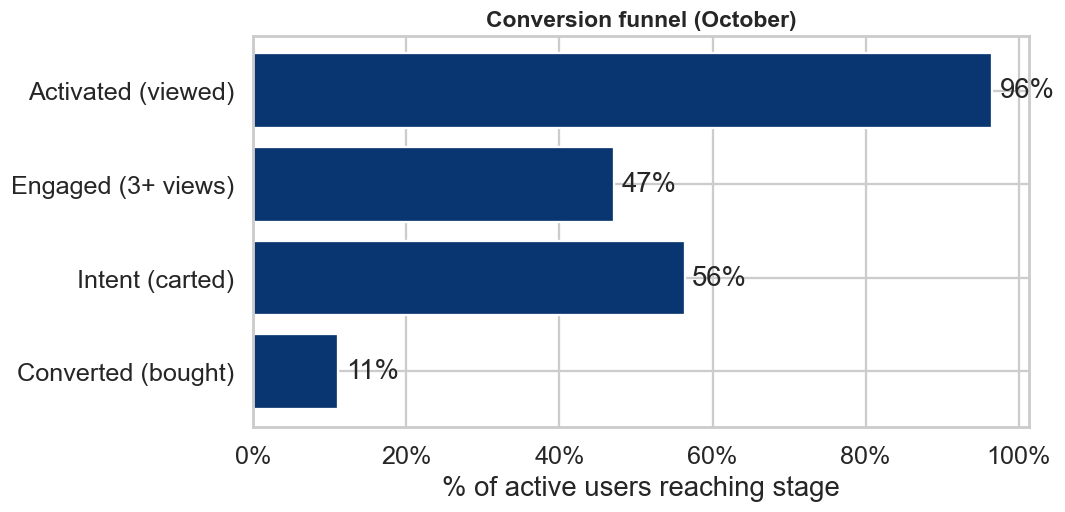

Step conversion:
  cart | viewed   : 58.4%
  buy  | carted   : 19.4%


In [8]:
type_counts = event_type_counts(events)   # one row per user: view / cart / purchase / remove counts

stages = {
    "Activated (viewed)": (type_counts["view"] >= 1).mean(),
    "Engaged (3+ views)": (type_counts["view"] >= 3).mean(),
    "Intent (carted)":    (type_counts["cart"] >= 1).mean(),
    "Converted (bought)": (type_counts["purchase"] >= 1).mean(),
}
funnel = pd.Series(stages)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(funnel.index)[::-1], (funnel.values * 100)[::-1],
               color=PALETTE[0], edgecolor="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% of active users reaching stage"); ax.set_title("Conversion funnel (October)")
for b, v in zip(bars, (funnel.values * 100)[::-1]):
    ax.text(v + 1, b.get_y() + b.get_height()/2, f"{v:.0f}%", va="center")
plt.show()

print("Step conversion:")
print(f"  cart | viewed   : {(type_counts['cart'] >= 1).sum() / (type_counts['view'] >= 1).sum():.1%}")
print(f"  buy  | carted   : {type_counts.loc[type_counts['cart'] >= 1, 'purchase'].ge(1).mean():.1%}")


**Insight:** The steep drop from *intent* to *converted* is the biggest single leak in
the funnel: a large share of shoppers add products to the cart but never complete a
purchase. Cart‑stage friction (checkout, price, hesitation) is where a recovery nudge has
the most surface area to work with - a hypothesis we return to in the experimentation
section.

### 4.2 Engagement distributions

How intense and how broad is a typical user's first‑month activity?

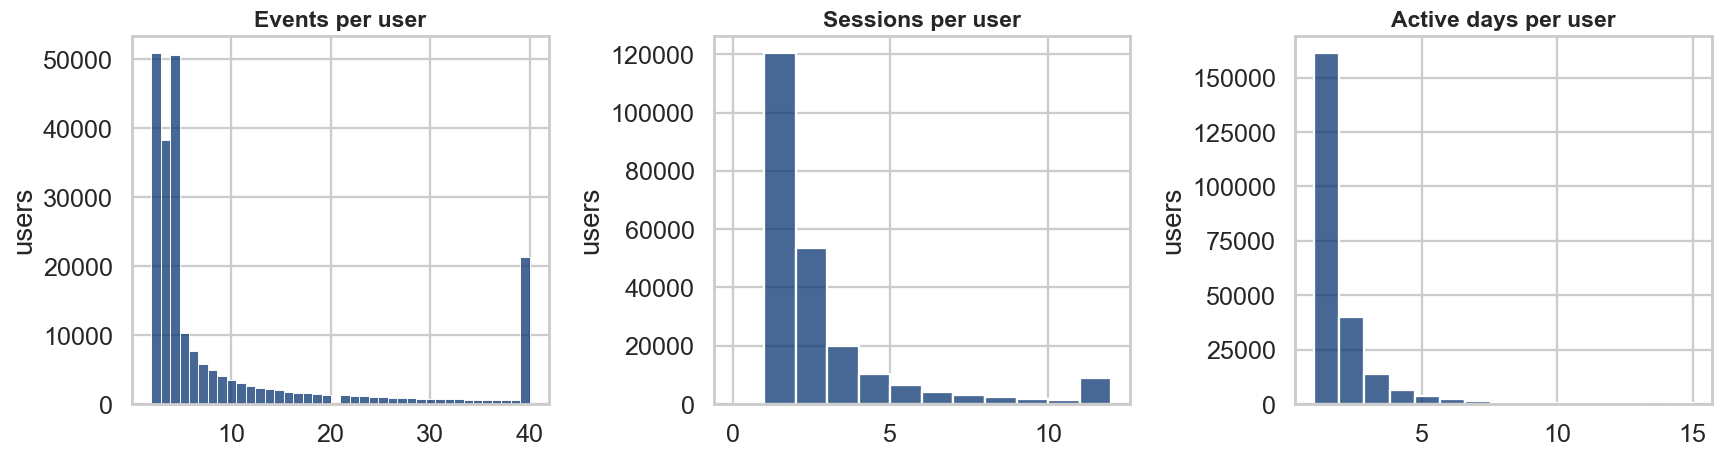

,n_events,n_sessions,cat_breadth,active_days
count,232079.00,232079.00,232079.00,232079.00
mean,16.01,3.03,3.53,1.68
std,45.63,9.63,5.82,1.65
min,2.00,0.00,1.00,1.00
25%,3.00,1.00,1.00,1.00
50%,4.00,1.00,1.00,1.00
75%,10.00,3.00,3.00,2.00
max,2999.00,1341.00,201.00,31.00


In [9]:
engagement = events.groupby("user_id").agg(
    n_events=("event_type", "count"),
    n_sessions=("user_session", "nunique"),
    cat_breadth=("category_id", "nunique"),
    active_days=("date", "nunique"),
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title, cap in [
    (axes[0], "n_events",   "Events per user",     40),
    (axes[1], "n_sessions", "Sessions per user",   12),
    (axes[2], "active_days","Active days per user", 15)]:
    sns.histplot(engagement[col].clip(upper=cap), bins=cap, ax=ax, color=PALETTE[0])
    ax.set_title(title); ax.set_ylabel("users"); ax.set_xlabel("")
plt.show()
engagement.describe().round(2)


**Insight:** Engagement is heavily **right‑skewed and single‑session dominated**: most
users appear in just one session on one day, with a long tail of habitual shoppers. This is
the classic retention challenge - the median user has almost no habit formed, so early
depth (multiple sessions / multiple days) is exactly the kind of signal we expect to
separate returners from churners.

### 4.3 When are users active?

Activity by hour of day and day of week - useful for timing any retention touch‑point.

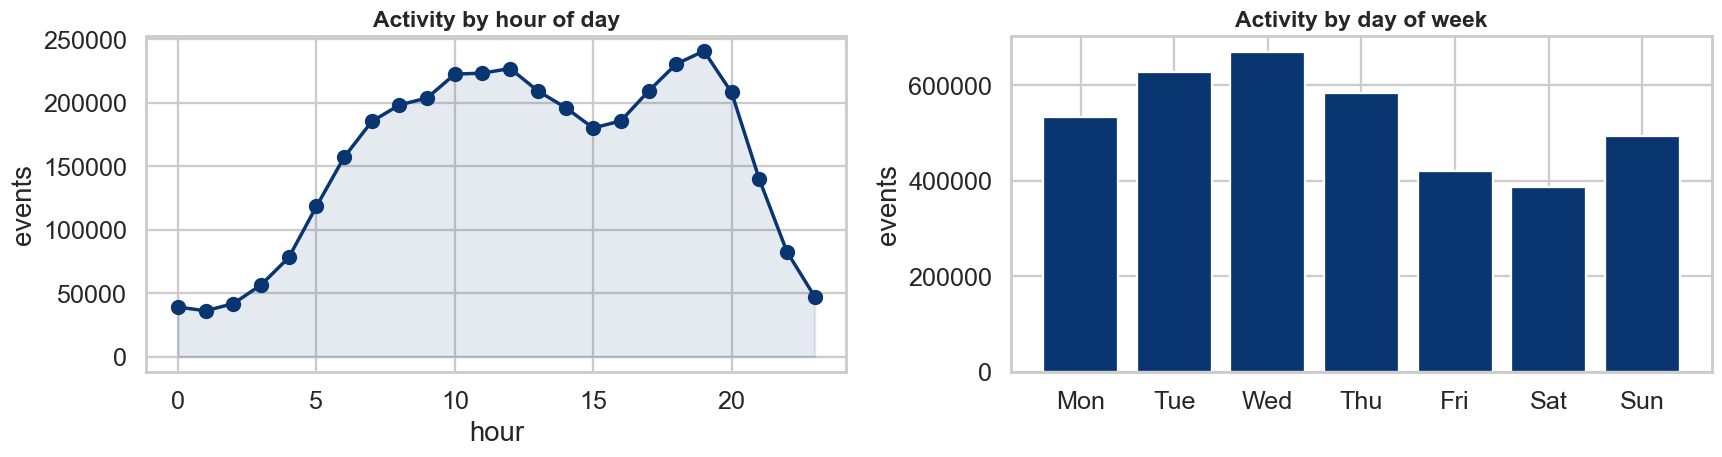

In [10]:
hour_counts = events.groupby("hour").size()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = events.groupby("dow").size().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(hour_counts.index, hour_counts.values, marker="o", color=PALETTE[0])
axes[0].fill_between(hour_counts.index, hour_counts.values, alpha=0.1, color=PALETTE[0])
axes[0].set_title("Activity by hour of day"); axes[0].set_xlabel("hour"); axes[0].set_ylabel("events")
axes[1].bar(range(7), dow_counts.values, color=PALETTE[0], edgecolor="white")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels([d[:3] for d in dow_order])
axes[1].set_title("Activity by day of week"); axes[1].set_ylabel("events")
plt.show()

**Insight:** Traffic concentrates in daytime/early‑evening hours and is fairly even
across weekdays, so a nudge campaign has a clear delivery window, and there is no strong
weekly seasonality that would confound a short experiment.

### 4.3b Conversion rate by hour, and how fast carts convert

Section 4.3 showed when users are active, here we check whether conversion efficiency varies
by time of day, and how long it typically takes a session to go from view to purchase, which are both
useful for timing a cart-recovery nudge.

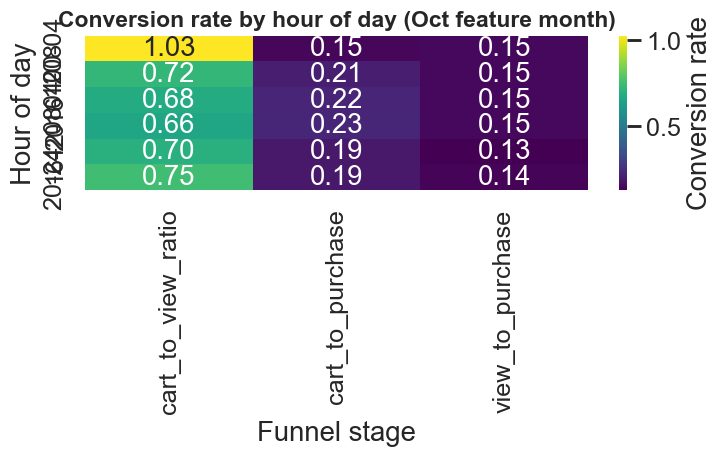

          cart_to_view_ratio  cart_to_purchase  view_to_purchase
hour_bin                                                        
00-04                  1.027             0.147             0.151
04-08                  0.724             0.205             0.149
08-12                  0.679             0.223             0.152
12-16                  0.662             0.229             0.151
16-20                  0.700             0.187             0.131
20-24                  0.751             0.188             0.141


In [11]:
events["hour_bin"] = pd.cut(events["hour"], bins=[-1, 3, 7, 11, 15, 19, 23],
                            labels=["00-04", "04-08", "08-12", "12-16", "16-20", "20-24"])
hourly_stage = events.groupby("hour_bin", observed=True)["event_type"].value_counts().unstack(fill_value=0)
hourly_rates = pd.DataFrame({
    # event-count ratio, NOT a per-user/session funnel: a cart can arrive without a matching
    # logged view in the same hour bin, and one view can precede several cart-adds, so this
    # can legitimately exceed 1.0 -- read it as "how cart-heavy is this hour", not a conversion rate
    "cart_to_view_ratio": hourly_stage["cart"] / hourly_stage["view"],
    "cart_to_purchase":   hourly_stage["purchase"] / hourly_stage["cart"],
    "view_to_purchase":   hourly_stage["purchase"] / hourly_stage["view"],
})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(hourly_rates, annot=True, fmt=".2f", cmap="viridis", ax=ax,
           cbar_kws={"label": "Conversion rate"})
ax.set_title("Conversion rate by hour of day (Oct feature month)")
ax.set_xlabel("Funnel stage"); ax.set_ylabel("Hour of day")
plt.tight_layout(); plt.show()
print(hourly_rates.round(3).to_string())

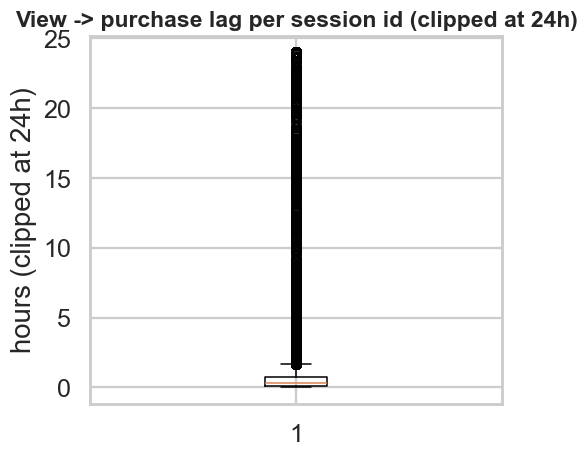

count    21724.00
mean         4.28
std         31.28
min          0.01
25%          0.13
50%          0.31
75%          0.75
max        727.10


In [42]:
view_t = (events[events["event_type"] == "view"]
          .groupby("user_session")["event_time"].min().rename("view_time"))
purch_t = (events[events["event_type"] == "purchase"]
           .groupby("user_session")["event_time"].min().rename("purchase_time"))
lag_df = view_t.to_frame().join(purch_t, how="inner")
lag_df["lag_hours"] = (lag_df["purchase_time"] - lag_df["view_time"]).dt.total_seconds() / 3600
lag = lag_df.loc[lag_df["lag_hours"] >= 0, "lag_hours"]

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.boxplot(lag.clip(upper=24), vert=True)
ax.set_title("View -> purchase lag per session id (clipped at 24h)")
ax.set_ylabel("hours (clipped at 24h)")
plt.tight_layout(); plt.show()
print(lag.describe().round(2).to_string())

**Insight:** Hourly conversion rates refine the "when are users active" picture from Section 4.3: the overnight window (00–04h) has the **highest cart-to-view event ratio (1.03)**, this is an event-count ratio, not a per-user funnel: it can and does exceed 1.0 here because a cart-add doesn't require a matching logged view in the same hour bin, and one view can precede several cart-adds, but the **lowest cart→purchase follow‑through (14.7%)**, while 12–16h has the best checkout efficiency (**22.9%**, with 08–12h close behind at 22.3%). View→purchase itself stays fairly flat all day (13–15%), so the story is entirely about *when carts get finished*, not when they get started — a late‑night cart nudge should expect a lower payoff than a midday one.

The lag distribution **per session id** sharpens the timing question further (grouped by
`user_session`; note session ids can recur/be reused across users or time windows in this feed,
so this is an approximate session join, not a guaranteed 1:1 link): the median view→purchase lag
is just **19 minutes (0.31h)**, and 75% of purchases complete within **45 minutes (0.75h)** of
the first view, but a long tail stretches to **727 hours (~30 days)** (mean 4.28h / SD 31.3h,
both dominated by outliers and not representative). The boxplot above is **clipped at 24h** so
the sub-1-hour bulk of the distribution is visible; the `describe()` output reports the
untruncated range. This means **Recommendation #1's 48‑hour cart‑abandonment window is far too slow for the bulk of would‑be buyers**: anyone who converts typically does so within the hour, so a 48‑hour trigger is really a long‑tail rescue mechanism, not the intervention that saves the median cart. A **tiered nudge**, fast (~1 hour) for the bulk of carts, with a slower 24-48h fallback for stragglers, would match the data better than a single fixed window.

### 4.4 Price & spend

Cosmetics is a **low‑ticket, high‑frequency** category. We look at item price and per‑user
purchase spend, which we later use to segment high‑ vs low‑value shoppers.

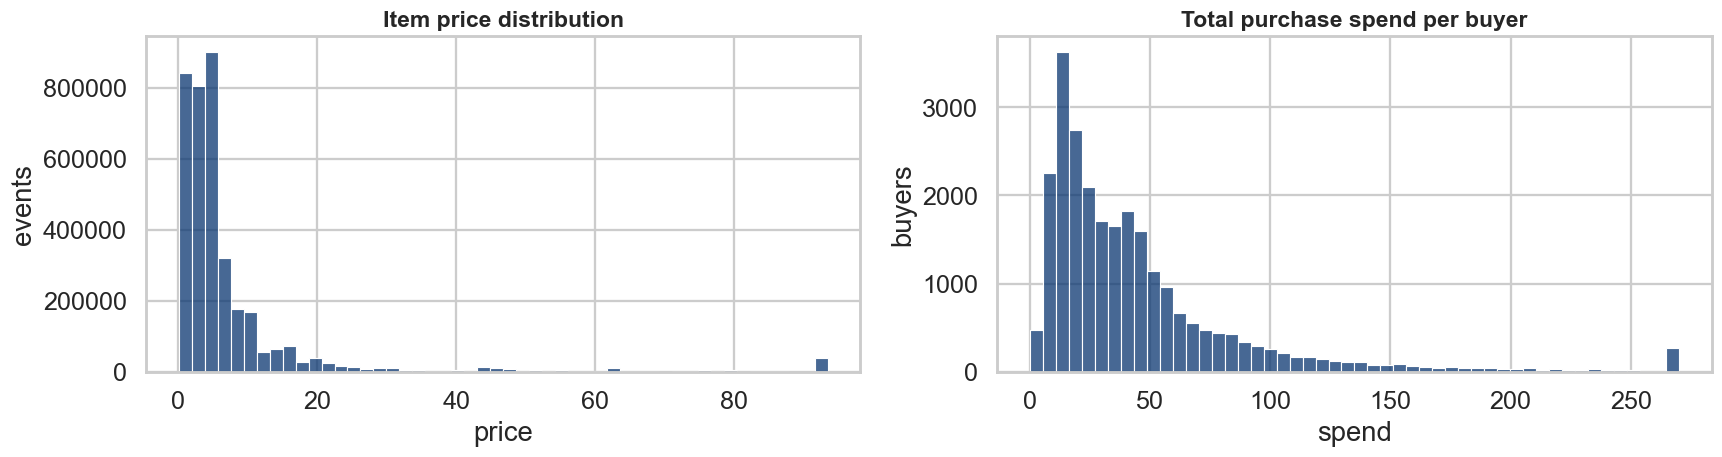

Median item price: 4.11 | Buyers: 25,755 | Median buyer spend: 32.38


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.histplot(events["price"].clip(upper=events["price"].quantile(0.99)),
             bins=50, ax=axes[0], color=PALETTE[0])
axes[0].set_title("Item price distribution"); axes[0].set_xlabel("price"); axes[0].set_ylabel("events")

spend = user_purchase_spend(events)
sns.histplot(spend.clip(upper=spend.quantile(0.99)), bins=50, ax=axes[1], color=PALETTE[0])
axes[1].set_title("Total purchase spend per buyer"); axes[1].set_xlabel("spend"); axes[1].set_ylabel("buyers")
plt.show()
print(f"Median item price: {events['price'].median():.2f} | "
      f"Buyers: {spend.size:,} | Median buyer spend: {spend.median():.2f}")


**Insight:** Prices cluster at the low end (median ≈ a few dollars), confirming an
impulse‑purchase category where **basket‑building and repeat visits**, not big individual
orders, drive value. Retention (getting people back) matters more here than maximising any
single checkout.

### 4.5 Revenue trend & the promotional calendar

Daily GMV (purchase value) over every month present in `DATA_DIR`, with a 7‑day moving
average. This matters for the churn label: **November contains Black Friday**, a demand
spike that pulls purchases forward.

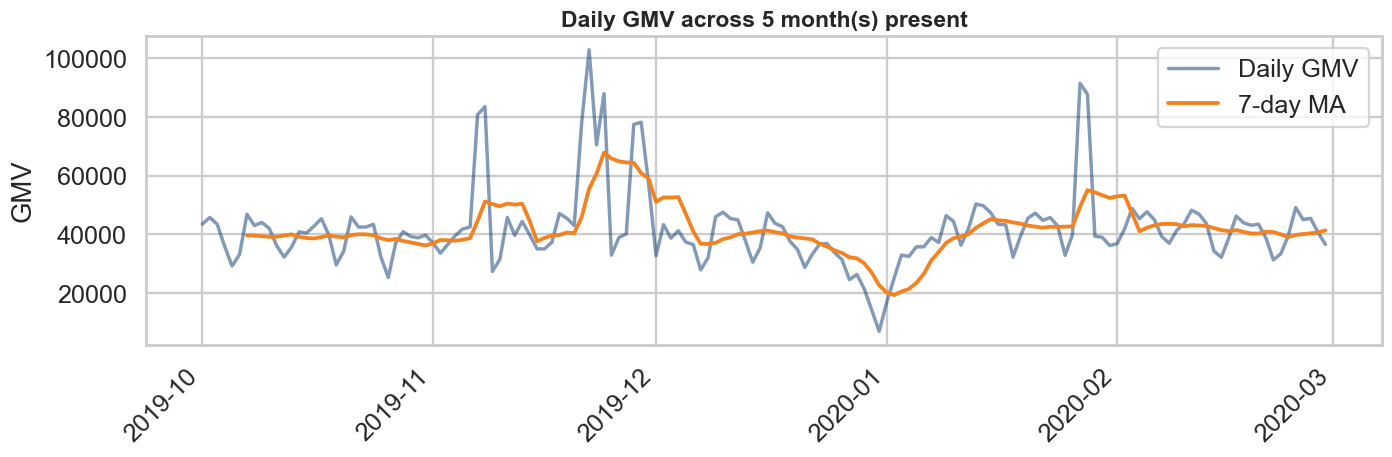

Months loaded: ['2019-Dec', '2019-Nov', '2019-Oct', '2020-Feb', '2020-Jan']


In [14]:
month_files = sorted(DATA_DIR.glob("2019-*.csv")) + sorted(DATA_DIR.glob("2020-*.csv"))
gmv_parts = []
for fp in month_files:
    d = pd.read_csv(fp, usecols=["event_time", "event_type", "price"])
    d = d[(d["event_type"] == "purchase") & (d["price"] > 0)]
    d["date"] = pd.to_datetime(d["event_time"], utc=True).dt.tz_convert(None).dt.normalize()
    gmv_parts.append(d.groupby("date")["price"].agg(gmv="sum", orders="count"))
daily = pd.concat(gmv_parts).sort_index()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["gmv"], color=PALETTE[0], alpha=.5, label="Daily GMV")
ax.plot(daily.index, daily["gmv"].rolling(7).mean(), color=PALETTE[1], lw=2.5, label="7-day MA")
ax.set_title(f"Daily GMV across {len(month_files)} month(s) present")
ax.set_ylabel("GMV"); ax.legend(); plt.xticks(rotation=45, ha="right"); plt.show()
print(f"Months loaded: {[f.stem for f in month_files]}")


**Insight:** On the full dataset GMV surges in **November (Black Friday)** and dips in
December as demand is pulled forward, before settling back toward the October baseline in
Jan–Feb. This is a **caveat for the churn label**: because the Nov–Dec label window overlaps
the promotional peak, some October users "return" only to chase Black Friday deals rather
than from organic habit, so the observed churn rate is likely a *lower bound*, and the model
partly learns promo‑responsiveness. Worth stating explicitly, and a reason to eventually
validate on a non‑promotional label window.

### 4.6 Cohort retention

Grouping users by their **first‑active week** and tracking what fraction return in later
weeks reveals the decay curve — the empirical shape of churn.

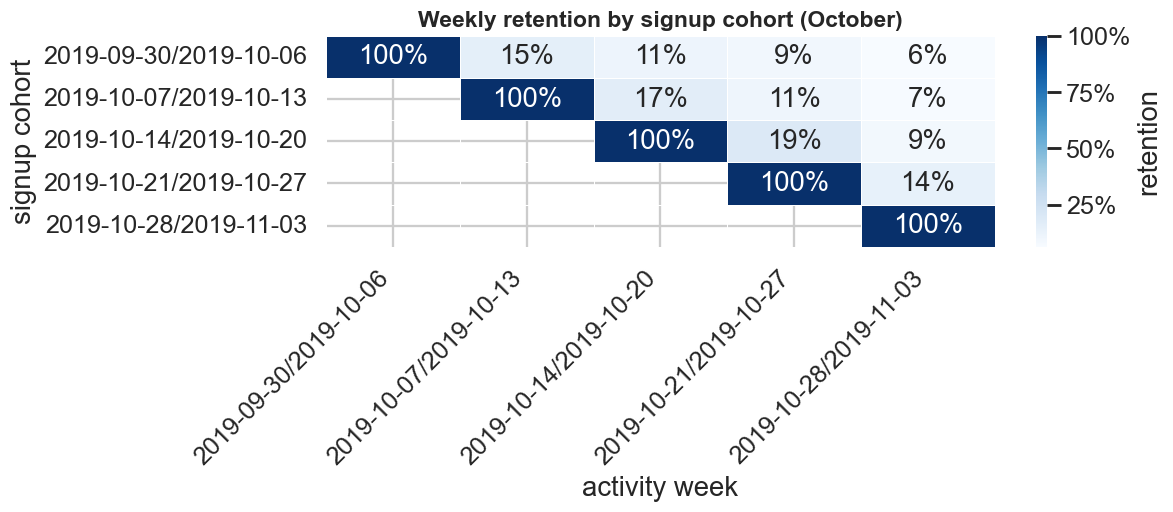

In [15]:
user_first = events.groupby("user_id")["event_time"].min()
cw = user_first.dt.to_period("W").astype(str).rename("cohort_week")
ev = events[["user_id", "event_time"]].merge(cw, on="user_id")
ev["activity_week"] = ev["event_time"].dt.to_period("W").astype(str)

cohort = ev.groupby(["cohort_week", "activity_week"])["user_id"].nunique().reset_index()
pivot = cohort.pivot(index="cohort_week", columns="activity_week", values="user_id")
sizes = pivot.apply(lambda r: r[r.first_valid_index()], axis=1)
# align each cohort to weeks-since-first for a clean triangular curve
retention = pivot.divide(sizes, axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues", linewidths=.5,
            cbar_kws={"label": "retention", "format": mtick.PercentFormatter(1.0)}, ax=ax)
ax.set_title("Weekly retention by signup cohort (October)")
ax.set_xlabel("activity week"); ax.set_ylabel("signup cohort")
plt.xticks(rotation=45, ha="right"); plt.show()

**Insight.** Retention falls off a cliff after week 0, the vast majority of a cohort
does not return the following week. That steep first‑step decay is precisely why a churn
model should focus on **week‑1 behavioural signals**: by the time inactivity is visible,
the user is already gone. (With the full dataset the cohort grid extends across months,
showing the longer‑horizon decay that motivates the 60‑day churn label.)

## 5. Defining churn without leakage

A single‑month label `churn = (days_since_last_activity ≥ 30)`
is mechanically the *same variable* as recency, and cannot even be observed with 31 days of
data. Feeding `recency` (or `retained_7d`) into the model then "predicts" the label from a
copy of itself.

Features are built **only from October**, the label is measured **only from
Nov–Dec**:

> **churn = 1** if an October‑active user has **no events at all in Nov–Dec** (did not
> return within ~60 days); **churn = 0** otherwise.

Because the two windows are disjoint, within‑October recency becomes a *legitimate*
predictor rather than a copy of the target.

In [16]:
def build_features(events, cutoff):
    """Leakage-free user features computed strictly on the feature window."""
    base = events.groupby("user_id").agg(
        first_seen=("event_time", "min"),
        last_seen=("event_time", "max"),
        n_events=("event_type", "count"),
        n_sessions=("user_session", "nunique"),
        cat_breadth=("category_id", "nunique"),
        brand_breadth=("brand", "nunique"),
        active_days=("date", "nunique"),
    )
    # per-event-type counts via the shared helper (index-aligned on user_id);
    # this replaces three slow groupby().apply(lambda ...) passes with one count
    counts = event_type_counts(events)
    base["n_views"]     = counts["view"]
    base["n_carts"]     = counts["cart"]
    base["n_purchases"] = counts["purchase"]

    f = base.reset_index()
    first_cart = (events.loc[events["event_type"] == "cart"]
                        .groupby("user_id")["event_time"].min())
    f = f.merge(first_cart.rename("first_cart"), on="user_id", how="left")
    f["days_to_first_cart"] = (f["first_cart"] - f["first_seen"]).dt.days
    f["has_cart"] = f["first_cart"].notna().astype(int)
    f["lifetime_days"] = (f["last_seen"] - f["first_seen"]).dt.days + 1
    f["avg_events_per_day"] = f["n_events"] / f["lifetime_days"]
    # within-window recency (measured at cutoff) -> legitimate, NOT the label
    f["days_since_last_active"] = (cutoff - f["last_seen"]).dt.days
    f = f.merge(user_purchase_spend(events).rename("total_spend"), on="user_id", how="left")
    f["total_spend"] = f["total_spend"].fillna(0.0)
    return f


def returning_users(paths):
    """Set of user_ids with at least one valid event in the label months."""
    users = set()
    for p in paths:
        chunk = pd.read_csv(p, usecols=["user_id", "event_type", "price"])
        chunk = chunk[chunk["event_type"].isin(EVENT_TYPES) & (chunk["price"] > 0)]
        users.update(chunk["user_id"].unique().tolist())
    return users


In [17]:
feat = build_features(events, CUTOFF)
print(f"Feature table: {feat.shape[0]:,} users x {feat.shape[1]} columns")


Feature table: 232,079 users x 18 columns


In [18]:
FEATURES = ["n_views", "n_carts", "n_purchases", "n_sessions",
            "cat_breadth", "active_days", "avg_events_per_day",
            "days_since_last_active", "days_to_first_cart"]
# brand_breadth dropped: near-collinear with cat_breadth (r=0.91) and added no independent signal.
# has_cart dropped: near-perfectly collinear with days_to_first_cart (r=-0.99) and had ~0
# permutation importance in HistGradientBoosting once that collinearity split the signal.

if HAS_LABELS:
    returned = returning_users(label_paths)
    feat["churn"] = (~feat["user_id"].isin(returned)).astype(int)
    print(f"Churn base rate: {feat['churn'].mean():.3f}")
else:
    print("[i] Label months absent — churn label is created when Nov–Dec CSVs are present.")

Churn base rate: 0.771


## 6. Modeling

Two complementary models are trained on the same leakage‑free features:

* **Logistic regression** - the *interpretable* model. The point of this report is
  *drivers*, and a logistic gives signed, readable coefficients plus a thresholdable
  probability.
* **HistGradientBoosting** - the *predictive benchmark*. A gradient‑boosted tree captures
  non‑linearities and interactions the logistic cannot, and answers "how much signal is
  really in these behaviours?". It needs no scaling and handles the skewed features natively.

Shared methodological choices: **no leaky features** (`retained_7d`, label‑derived recency
excluded); **class imbalance** handled (`class_weight="balanced"` for logistic,
`scale_pos_weight`‑style balancing via sample weights for the tree) and reported with
**PR‑AUC vs a base‑rate baseline** and **precision/recall**, not accuracy; a
**multicollinearity check** before reading coefficients; and **permutation importance** as a
model‑agnostic importance measure comparable across both models.

In [19]:
def make_logistic():
    """Interpretable model; hyperparameters live in LOGIT_PARAMS (configuration cell)."""
    return LogisticRegression(**LOGIT_PARAMS)


def make_hgb():
    """Predictive benchmark; hyperparameters live in HGB_PARAMS (configuration cell)."""
    return HistGradientBoostingClassifier(**HGB_PARAMS)


def balanced_sample_weight(y):
    """Up-weight the minority class so the tree sees a balanced problem."""
    y = np.asarray(y)
    return np.where(y == 1, (y == 0).sum() / (y == 1).sum(), 1.0)


def prepare_design_matrix(feat):
    """Model-ready X: select FEATURES and encode "never carted" as beyond the window."""
    X = feat[FEATURES].copy()
    X["days_to_first_cart"] = X["days_to_first_cart"].fillna(DAYS_TO_CART_FILL)
    return X


def report_high_correlations(X, threshold=CORR_FLAG):
    """Flag |r| > threshold pairs (matters for reading the logistic coefficients)."""
    upper = np.triu(np.ones((X.shape[1],) * 2), 1).astype(bool)
    pairs = X.corr().where(upper).stack()
    pairs = pairs[pairs.abs() > threshold]
    print(f"Strongly correlated feature pairs (|r|>{threshold}):",
          "\n" + pairs.round(2).to_string() if len(pairs) else "none")


In [20]:
if HAS_LABELS:
    X = prepare_design_matrix(feat)
    y = feat["churn"]
    report_high_correlations(X)
else:
    print("[i] Both models run once the full dataset (Nov–Dec) is present.")


Strongly correlated feature pairs (|r|>0.7): 
n_carts  cat_breadth    0.7


In [21]:
if HAS_LABELS:
    # One shared 70/30 split, reused for §6 metrics, §6b importance and §8.1 calibration
    # (identical seed + stratification -> identical split everywhere, computed once).
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

    baseline_pr_auc = average_precision_score(
        y_test, DummyClassifier(strategy="most_frequent")
                .fit(X_train, y_train).predict_proba(X_test)[:, 1])

    # --- Logistic (scaled) ----------------------------------------------------
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
    logit = make_logistic().fit(X_train_s, y_train)
    p_logit = logit.predict_proba(X_test_s)[:, 1]

    # --- HistGradientBoosting (unscaled, balanced via sample weights) ---------
    hgb = make_hgb().fit(X_train, y_train, sample_weight=balanced_sample_weight(y_train))
    p_hgb = hgb.predict_proba(X_test)[:, 1]


In [22]:
if HAS_LABELS:
    metrics_df = pd.DataFrame({
        "ROC-AUC": [roc_auc_score(y_test, p_logit), roc_auc_score(y_test, p_hgb)],
        "PR-AUC":  [average_precision_score(y_test, p_logit),
                    average_precision_score(y_test, p_hgb)],
    }, index=["Logistic", "HistGradientBoosting"]).round(3)

    print(f"\nBase-rate PR-AUC baseline: {baseline_pr_auc:.3f}\n")
    print(metrics_df.to_string())
    print("\nLogistic — classification report @0.5:\n",
          classification_report(y_test, (p_logit >= .5).astype(int), digits=3))
    print("HGB — confusion matrix @0.5:\n",
          confusion_matrix(y_test, (p_hgb >= .5).astype(int)))



Base-rate PR-AUC baseline: 0.771

                      ROC-AUC  PR-AUC
Logistic                0.801   0.926
HistGradientBoosting    0.822   0.938

Logistic — classification report @0.5:
               precision    recall  f1-score   support

           0      0.440     0.689     0.537     15956
           1      0.889     0.740     0.807     53668

    accuracy                          0.728     69624
   macro avg      0.664     0.714     0.672     69624
weighted avg      0.786     0.728     0.745     69624

HGB — confusion matrix @0.5:
 [[11599  4357]
 [13899 39769]]


In [23]:
if HAS_LABELS:
    logit_coef = pd.Series(logit.coef_[0], index=FEATURES).sort_values()
    logit_perm = pd.Series(
        permutation_importance(logit, X_test_s, y_test, scoring="average_precision",
                               n_repeats=PERM_REPEATS_DRIVERS,
                               random_state=RANDOM_STATE).importances_mean, index=FEATURES)
    hgb_perm = pd.Series(
        permutation_importance(hgb, X_test, y_test, scoring="average_precision",
                               n_repeats=PERM_REPEATS_DRIVERS,
                               random_state=RANDOM_STATE).importances_mean, index=FEATURES)

    drivers = pd.DataFrame({
        "logit_coef":   logit_coef,
        "log_perm_imp": logit_perm,
        "hgb_perm_imp": hgb_perm,
    }).sort_values("hgb_perm_imp", ascending=False)
    drivers["logit_sign"] = np.where(drivers["logit_coef"] > 0, "risk (+)", "protective (-)")
    # "agree" = non-zero coefficient AND positive permutation importance in BOTH models
    drivers["agree"] = ((drivers["logit_coef"] != 0)
                        & (drivers["log_perm_imp"] > 0)
                        & (drivers["hgb_perm_imp"] > 0))

    print("\nDriver table (sorted by HGB permutation importance):")
    print(drivers.round(4).to_string())
    print("\nFeatures where sign is consistent AND both models rank it with positive permutation importance:")
    print(drivers[drivers["agree"]].index.tolist())



Driver table (sorted by HGB permutation importance):
                        logit_coef  log_perm_imp  hgb_perm_imp      logit_sign  agree
days_since_last_active      0.6334        0.0539        0.0241        risk (+)   True
cat_breadth                -0.5949        0.0211        0.0134  protective (-)   True
active_days                -0.7957        0.0221        0.0095  protective (-)   True
n_views                     0.1191        0.0019        0.0039        risk (+)   True
n_carts                     0.1264        0.0025        0.0022        risk (+)   True
avg_events_per_day         -0.1111        0.0030        0.0015  protective (-)   True
n_sessions                  0.0714        0.0009        0.0007        risk (+)   True
days_to_first_cart         -0.0666        0.0036        0.0003  protective (-)   True
n_purchases                -0.0308        0.0003        0.0000  protective (-)   True

Features where sign is consistent AND both models rank it with positive permutation i

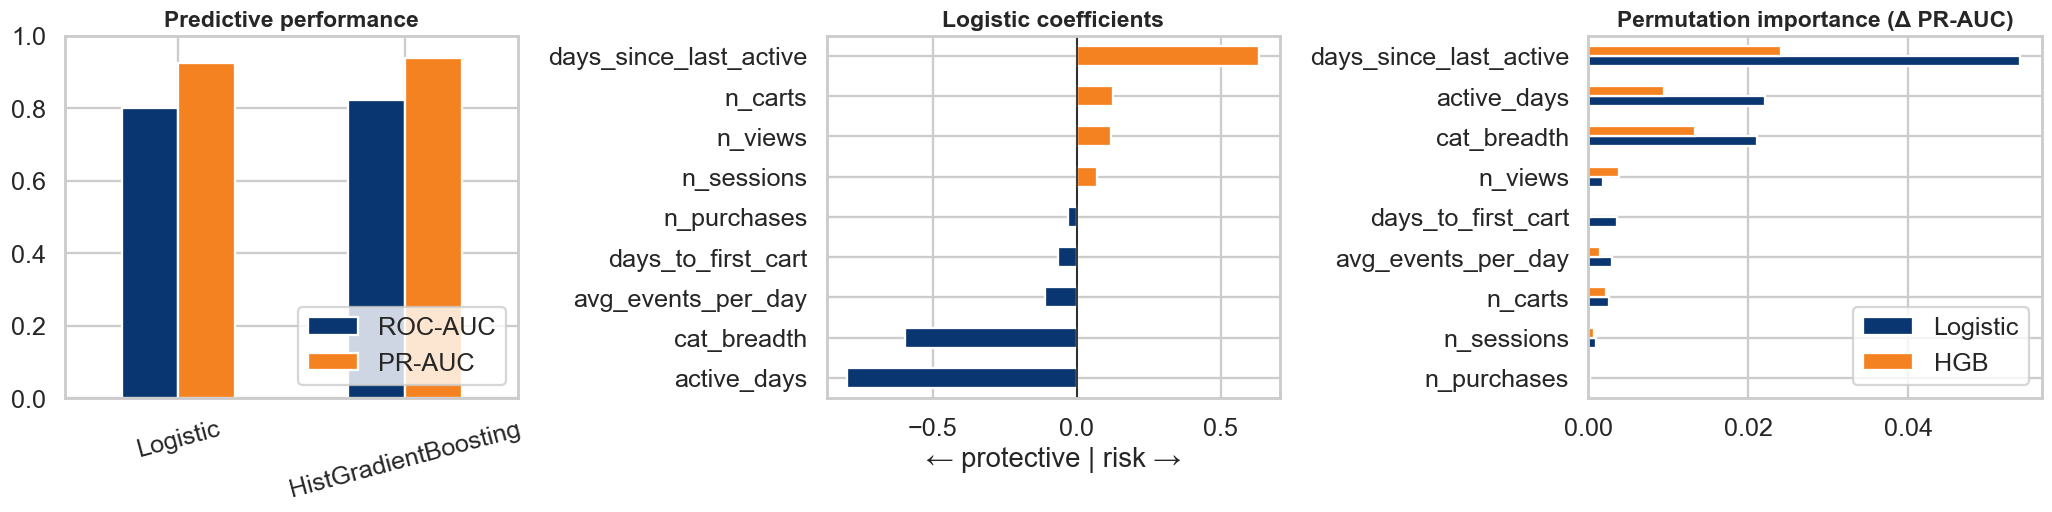

In [24]:
if HAS_LABELS:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    # (a) model comparison
    metrics_df.plot(kind="bar", ax=axes[0], color=[PALETTE[0], PALETTE[1]], rot=15)
    axes[0].set_title("Predictive performance"); axes[0].set_ylim(0, 1)
    axes[0].legend(loc="lower right")
    # (b) logistic coefficients (direction)
    logit_coef.plot(kind="barh", ax=axes[1],
                    color=[PALETTE[1] if v > 0 else PALETTE[0] for v in logit_coef])
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_title("Logistic coefficients"); axes[1].set_xlabel("← protective | risk →")
    # (c) permutation importance: logistic vs tree
    perm_df = pd.DataFrame({"Logistic": logit_perm, "HGB": hgb_perm})
    perm_df = perm_df.loc[perm_df.max(axis=1).sort_values().index]
    perm_df.plot(kind="barh", ax=axes[2], color=[PALETTE[0], PALETTE[1]])
    axes[2].set_title("Permutation importance (Δ PR-AUC)")
    plt.tight_layout(); plt.show()
else:
    print("[i] Comparison, coefficient & importance charts render with the full dataset.")


The churn base rate is **77.1%** (of 232,079 Oct users, only ~23% returned in Nov–Dec). **Read ROC‑AUC as the headline metric - 0.801 (logistic) vs 0.822 (HistGradientBoosting)** — both clear chance (0.5) by a wide, decision‑useful margin. The PR‑AUC numbers (0.926 vs 0.938) look far more impressive, but they are **inflated by the 77% positive‑class base rate**: a no‑skill classifier already scores ~0.771 on PR‑AUC here, so it is the headroom above that baseline, not the absolute value, that reflects real skill. The gap between the two models is small (≤0.02 on both metrics), so HistGradientBoosting's extra flexibility buys only a marginal lift - the logistic already captures most of the structure and, given its interpretability, is the better deployment choice.

**A limitation to keep in view:** at the default 0.5 threshold the logistic model's **precision on the minority "will return" class (class 0) is only ~0.44** - when it predicts a user will come back, it is right less than half the time. Churners themselves are flagged well (class‑1 precision 0.89), but positively identifying loyal users is much harder at this base rate, which is exactly why the calibrated, cost‑weighted targeting in §8, not a raw 0.5 cutoff, is the right way to turn these scores into actions.

For *drivers*, trusting only features where the **logistic sign** and **both models' permutation importance** agree is especially clean now: after dropping the two collinear predictors (`brand_breadth`, `has_cart`), **all nine remaining features pass the agreement test**. The primary drivers are **`days_since_last_active` (risk, by far the strongest signal)** with **`cat_breadth` and `active_days` (both protective)** close behind; `n_views`, `n_carts`, `n_sessions`, `avg_events_per_day`, `days_to_first_cart` and `n_purchases` contribute consistent but smaller signal. Dropping `has_cart` also resolved the earlier instability: `days_to_first_cart`'s logistic coefficient collapsed from ‑0.57 to ‑0.07 once its near‑perfect collinear partner (r=‑0.99) was removed, confirming the two had been splitting a single signal across two columns. This triangulation is what avoids the earlier "window‑shopper" over‑claim, where one unstable coefficient was narrated as a finding.

### 6b. Validation: cross-validation, baselines & feature importance

Before trusting the numbers, three checks: (1) **stratified 5-fold cross-validation** so the
metrics are mean ± std across folds, not a single lucky split; (2) **baselines** (majority
class and a recency-only rule) so the models' lift is explicit; (3) **permutation importance**
with error bars for both models, the model-agnostic driver measure. All scaling / class
weighting is fit inside each fold to avoid leakage.


In [25]:
# Fold-level scorers: each returns churn scores for a fold's test rows.
# All scaling / class weighting is fit INSIDE the fold to avoid leakage.
RECENCY_COL = "days_since_last_active"


def score_majority(Xtr, ytr, Xte):
    """Constant P(churn) -> ROC-AUC 0.5, PR-AUC = prevalence."""
    return np.full(len(Xte), ytr.mean())


def score_recency(Xtr, ytr, Xte):
    """The single strongest signal, as an unfitted rank."""
    return Xte[RECENCY_COL].to_numpy()


def score_logistic(Xtr, ytr, Xte):
    sc = StandardScaler().fit(Xtr)
    m = make_logistic().fit(sc.transform(Xtr), ytr)
    return m.predict_proba(sc.transform(Xte))[:, 1]


def score_hgb(Xtr, ytr, Xte):
    m = make_hgb().fit(Xtr, ytr, sample_weight=balanced_sample_weight(ytr))
    return m.predict_proba(Xte)[:, 1]


SCORERS = {
    "Baseline · majority class": score_majority,
    "Baseline · recency only":   score_recency,
    "Logistic regression":       score_logistic,
    "HistGradientBoosting":      score_hgb,
}


In [26]:
if HAS_LABELS:
    y_arr = y.to_numpy()
    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for name, scorer in SCORERS.items():
        aucs, aps = [], []
        for tr_idx, te_idx in skf.split(X, y_arr):
            Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
            ytr, yte = y_arr[tr_idx], y_arr[te_idx]
            s = scorer(Xtr, ytr, Xte)
            aucs.append(roc_auc_score(yte, s))
            aps.append(average_precision_score(yte, s))
        rows.append([name, np.mean(aucs), np.std(aucs), np.mean(aps), np.std(aps)])

    cv = pd.DataFrame(rows, columns=["model", "ROC-AUC", "roc_sd", "PR-AUC", "pr_sd"])
    cv_show = cv.assign(**{
        "ROC-AUC (mean±sd)": cv.apply(lambda r: f"{r['ROC-AUC']:.3f} ± {r['roc_sd']:.3f}", axis=1),
        "PR-AUC (mean±sd)":  cv.apply(lambda r: f"{r['PR-AUC']:.3f} ± {r['pr_sd']:.3f}", axis=1),
    })[["model", "ROC-AUC (mean±sd)", "PR-AUC (mean±sd)"]]
    print(f"5-fold stratified CV  (PR-AUC baseline = churn prevalence = {y_arr.mean():.3f})\n")
    print(cv_show.to_string(index=False))


5-fold stratified CV  (PR-AUC baseline = churn prevalence = 0.771)

                    model ROC-AUC (mean±sd) PR-AUC (mean±sd)
Baseline · majority class     0.500 ± 0.000    0.771 ± 0.000
  Baseline · recency only     0.739 ± 0.002    0.893 ± 0.001
      Logistic regression     0.801 ± 0.001    0.926 ± 0.001
     HistGradientBoosting     0.823 ± 0.001    0.939 ± 0.000


The models should clear both baselines: majority-class sits at ROC-AUC 0.50 (PR-AUC ≈ base
rate), and recency-only shows how much of the signal is just "how recently were they active
in October". The gap between recency-only and the full models is the value added by the rest
of the behavioural features. Small fold-to-fold std (tight ± values) means the estimate is
stable and not driven by one split.

Note: the driver table in §6 uses 8 permutation repeats for speed; the chart below uses 10
repeats to tighten the error bars, the tiny differences between the two tables are pure
resampling noise.


               feature  logit  logit_sd    hgb  hgb_sd
days_since_last_active 0.0540    0.0007 0.0241  0.0004
           cat_breadth 0.0211    0.0005 0.0134  0.0003
           active_days 0.0221    0.0004 0.0095  0.0002
               n_views 0.0019    0.0003 0.0038  0.0002
               n_carts 0.0026    0.0004 0.0022  0.0002
    avg_events_per_day 0.0030    0.0001 0.0015  0.0001
            n_sessions 0.0010    0.0003 0.0007  0.0001
    days_to_first_cart 0.0036    0.0003 0.0003  0.0001
           n_purchases 0.0003    0.0000 0.0000  0.0000


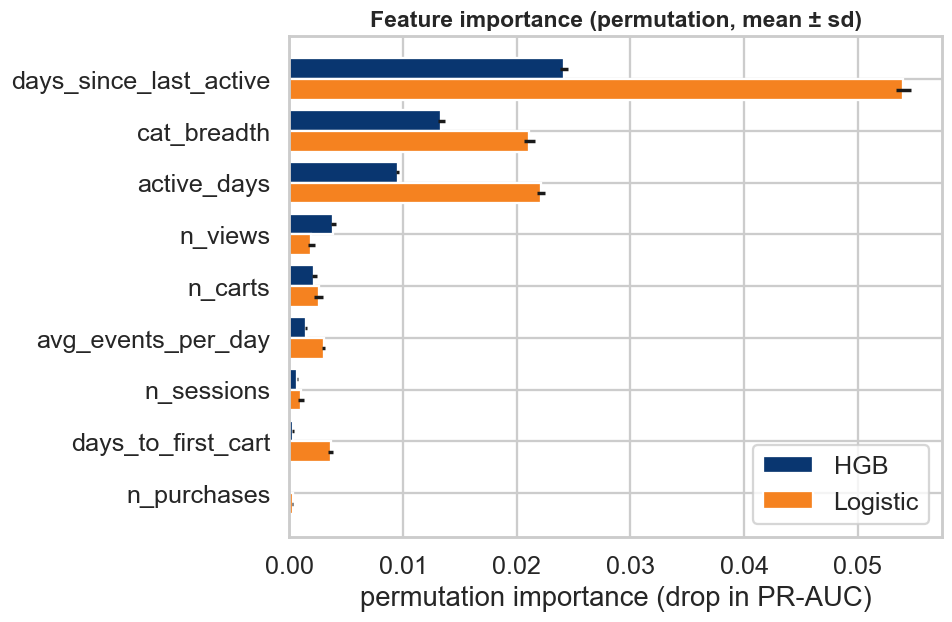

In [27]:
if HAS_LABELS:
    # Pipeline lets permutation_importance shuffle UNSCALED columns for the logistic;
    # the HGB from §6 is reused as-is (refitting with the same data/params/seed is identical).
    logit_pipe = Pipeline([("sc", StandardScaler()),
                           ("lr", make_logistic())]).fit(X_train, y_train)

    perm_logit = permutation_importance(logit_pipe, X_test, y_test,
                                        scoring="average_precision",
                                        n_repeats=PERM_REPEATS_FINAL, random_state=RANDOM_STATE)
    perm_hgb = permutation_importance(hgb, X_test, y_test,
                                      scoring="average_precision",
                                      n_repeats=PERM_REPEATS_FINAL, random_state=RANDOM_STATE)

    imp = (pd.DataFrame({"feature": FEATURES,
                         "logit": perm_logit.importances_mean, "logit_sd": perm_logit.importances_std,
                         "hgb": perm_hgb.importances_mean,  "hgb_sd": perm_hgb.importances_std})
           .sort_values("hgb", ascending=False).reset_index(drop=True))
    print(imp.round(4).to_string(index=False))

    order = imp.sort_values("hgb")
    ypos = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(ypos + 0.2, order["hgb"],   height=0.4, xerr=order["hgb_sd"],   label="HGB",      color=PALETTE[0])
    ax.barh(ypos - 0.2, order["logit"], height=0.4, xerr=order["logit_sd"], label="Logistic", color=PALETTE[1])
    ax.set_yticks(ypos); ax.set_yticklabels(order["feature"])
    ax.set_xlabel("permutation importance (drop in PR-AUC)")
    ax.set_title("Feature importance (permutation, mean ± sd)")
    ax.legend(); plt.tight_layout(); plt.show()


Trust a driver only where both models agree and the bar clearly exceeds its error bar.
Features whose importance is within noise of zero (e.g. a redundant partner of another feature)
can be dropped without hurting the model.

Recency alone reaches ROC‑AUC 0.74; the full behavioural model adds ~0.08 to reach 0.82, driven mainly by category breadth and activity spread. Because non‑return is the majority class (77%), PR‑AUC (~0.94) largely reflects prevalence - ROC‑AUC and the lift over the recency baseline are the honest headline metrics.

## 7. Value segmentation (RFM + K‑means)

Rather than a single median split, buyers are segmented on classic **RFM** features -
**R**ecency (days since last purchase, at the Nov‑1 cutoff), **F**requency (purchase count),
**M**onetary (total spend) - following common practice on this dataset. Features are
log‑transformed and Min‑Max scaled, then clustered with **K‑means**; k is chosen with an
elbow on inertia.

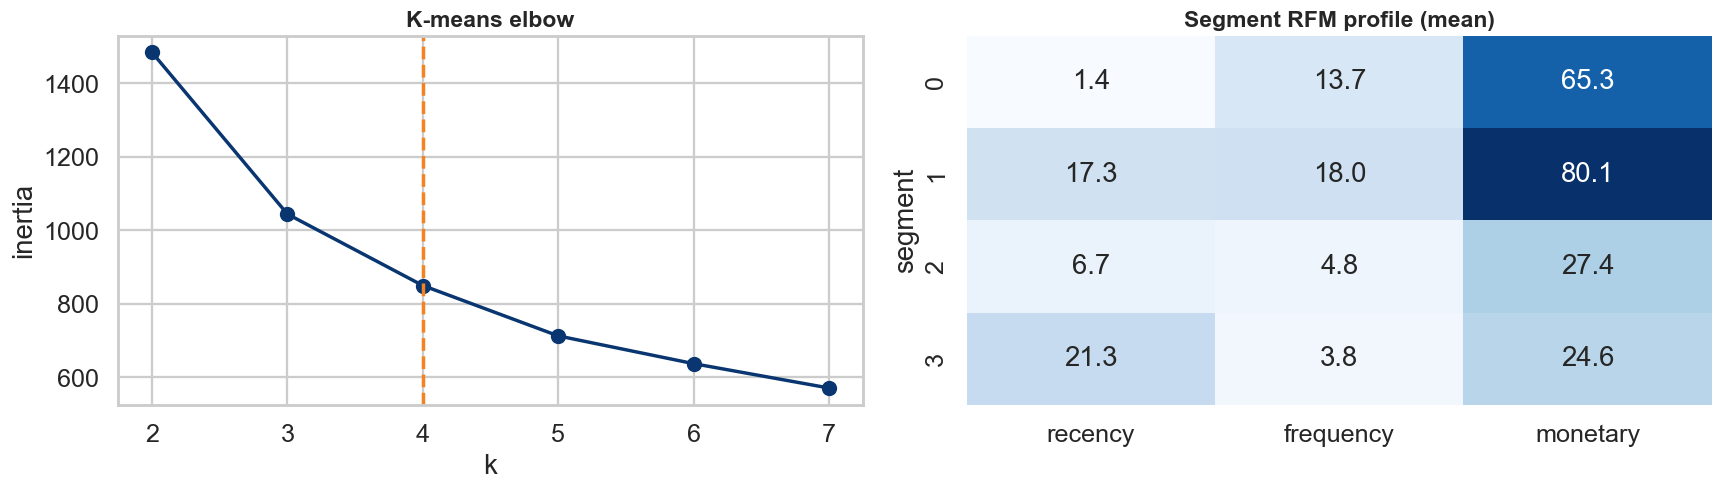

Segment sizes: {0: 3268, 1: 7743, 2: 5215, 3: 9529}

Segment RFM profile (mean):
         recency  frequency  monetary
segment                              
0            1.4       13.7      65.3
1           17.3       18.0      80.1
2            6.7        4.8      27.4
3           21.3        3.8      24.6

Churn rate per RFM segment:
segment
0    0.379
1    0.421
2    0.562
3    0.657


In [28]:
purchases = events[events["event_type"] == "purchase"]
rfm = purchases.groupby("user_id").agg(
    last_purchase=("event_time", "max"),
    frequency=("event_time", "count"),
    monetary=("price", "sum"),
)
rfm["recency"] = (CUTOFF - rfm["last_purchase"]).dt.days
rfm = rfm[["recency", "frequency", "monetary"]]
rfm_scaled = MinMaxScaler().fit_transform(np.log1p(rfm))

rfm_inertia = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(rfm_scaled).inertia_
               for k in RFM_K_RANGE]
km = KMeans(n_clusters=K_RFM, n_init=10, random_state=RANDOM_STATE).fit(rfm_scaled)
rfm["segment"] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
axes[0].plot(list(RFM_K_RANGE), rfm_inertia, marker="o", color=PALETTE[0])
axes[0].axvline(K_RFM, ls="--", color=PALETTE[1]); axes[0].set_title("K-means elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
profile = rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean()
segment_sizes = rfm["segment"].value_counts().sort_index()
sns.heatmap(profile.round(1), annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            cbar=False)
axes[1].set_title("Segment RFM profile (mean)")
plt.tight_layout(); plt.show()
print("Segment sizes:", segment_sizes.to_dict())
print("\nSegment RFM profile (mean):")
print(profile.round(1).to_string())

if HAS_LABELS:
    seg_churn = rfm.join(feat.set_index("user_id")["churn"]).groupby("segment")["churn"].mean()
    print("\nChurn rate per RFM segment:")
    print(seg_churn.round(3).to_string())
else:
    print("\n[i] Churn rate per segment populates once labels (Nov-Dec) are present.")


**Insight:** The 4 clusters separate into recognisable value tiers, and churn rises as recency worsens and frequency/spend drop:

| Segment | Recency (days) | Frequency | Monetary | Size | Churn rate |
|---|---|---|---|---|---|
| 0 — Champions | 1.4 | 13.7 | $65.3 | 3,268 | **37.9%** |
| 1 — High‑value, slipping | 17.3 | 18.0 | $80.1 | 7,743 | **42.1%** |
| 2 — Mid‑value, recent | 6.7 | 4.8 | $27.4 | 5,215 | **56.2%** |
| 3 — One‑time / low‑value | 21.3 | 3.8 | $24.6 | 9,529 | **65.7%** |

Segment 1 is the sharpest confirmation of the framing above: it has the **highest frequency and monetary value of any segment**, yet a 17‑day recency gap already pushes its churn rate above the champions segment, exactly the **high‑value buyers showing early drop‑off signals** pattern that should be flagged first, since losing them is the costliest mistake. Segment 3, the largest group at 9,529 buyers, combines the worst recency, frequency and monetary profile with the highest churn rate (65.7%) - a one‑time‑buyer tier where further retention investment has the lowest expected payoff.

## 7b. Behavioral user profiling (beyond RFM)

RFM only describes **purchasers**, but most users in the feature month never buy
anything, so an RFM-only view is silent about the majority of traffic. This section clusters
**every** user (not just buyers) on recency plus raw behavior counts, which are `view_cnt`, `cart_cnt`,
`remove_cnt`, `purchase_cnt`, to turn the funnel drop-off from Section 4.1 into named,
actionable personas.

Computed strictly on the **Oct feature window** (same `events`/`CUTOFF` as the churn label), so
there is no leakage risk from mixing this into the model - it is a descriptive companion to the
churn prediction, not a model input. Recall `events` already excludes single-event bounces
(Section 3's cleaning rule), so the lowest-engagement persona below is "2+ events, minimal
depth," not literal one-time visitors.

In [29]:
behavior = (event_type_counts(events)     # all four columns guaranteed by the helper
            .rename(columns={"view": "view_cnt", "cart": "cart_cnt",
                             "remove_from_cart": "remove_cnt", "purchase": "purchase_cnt"}))

recency = (CUTOFF - events.groupby("user_id")["event_time"].max()).dt.days.rename("recency_days")
prof_feat = (behavior
             .join(recency)
             .join(user_purchase_spend(events).rename("monetary")))
prof_feat["monetary"] = prof_feat["monetary"].fillna(0.0)

PROF_COLS = ["recency_days", "purchase_cnt", "monetary", "view_cnt", "cart_cnt", "remove_cnt"]
prof_log = prof_feat[PROF_COLS].apply(np.log1p)
prof_scaled = pd.DataFrame(MinMaxScaler().fit_transform(prof_log),
                           index=prof_feat.index, columns=PROF_COLS)
print(f"Behavioral profile table: {prof_scaled.shape[0]:,} users x {prof_scaled.shape[1]} features")


Behavioral profile table: 232,079 users x 6 features


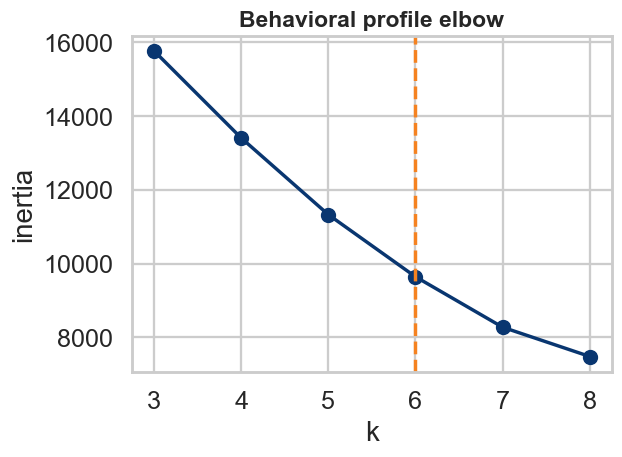

In [30]:
persona_inertia = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(prof_scaled).inertia_
                   for k in PERSONA_K_RANGE]
km_personas = KMeans(n_clusters=K_PERSONA, n_init=10, random_state=RANDOM_STATE).fit(prof_scaled)
prof_feat["persona"] = km_personas.labels_

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(list(PERSONA_K_RANGE), persona_inertia, marker="o", color=PALETTE[0])
ax.axvline(K_PERSONA, ls="--", color=PALETTE[1])
ax.set_title("Behavioral profile elbow"); ax.set_xlabel("k"); ax.set_ylabel("inertia")
plt.tight_layout(); plt.show()


In [31]:
conv = events.merge(prof_feat["persona"], left_on="user_id", right_index=True)
stage = conv.groupby("persona")["event_type"].value_counts().unstack(fill_value=0)
conv_rates = pd.DataFrame({
    "view_to_cart":     stage["cart"] / stage["view"],
    "cart_to_purchase": stage["purchase"] / stage["cart"],
    "view_to_purchase": stage["purchase"] / stage["view"],
})

size = prof_feat["persona"].value_counts().sort_index()
pct = (size / size.sum()).rename("pct")
medians = prof_feat.groupby("persona")[PROF_COLS].median()

profile_table = pd.concat([size.rename("n_users"), pct.round(3), medians.round(1),
                           conv_rates.round(3)], axis=1)
print(profile_table.to_string())

         n_users    pct  recency_days  purchase_cnt  monetary  view_cnt  cart_cnt  remove_cnt  view_to_cart  cart_to_purchase  view_to_purchase
persona                                                                                                                                        
0          54143  0.233           9.0           0.0       0.0       3.0       0.0         0.0         0.109             0.008             0.001
1          15888  0.068          16.0           5.0      27.6       7.0       8.0         2.0         0.894             0.601             0.537
2         111339  0.480          25.0           0.0       0.0       1.0       2.0         0.0         0.815             0.002             0.002
3          14930  0.064           9.0           0.0       0.0      12.0      15.0         7.0         1.090             0.000             0.000
4          27282  0.118           1.0           0.0       0.0       3.0       0.0         0.0         0.321             0.021           

In [32]:
if HAS_LABELS:
    persona_churn = prof_feat.join(feat.set_index("user_id")["churn"]).groupby("persona")["churn"].mean()
    print("\nChurn rate per behavioral persona:")
    print(persona_churn.round(3).to_string())
else:
    print("[i] Persona churn rate populates once labels (Nov-Dec) are present.")


Churn rate per behavioral persona:
persona
0    0.765
1    0.650
2    0.911
3    0.501
4    0.581
5    0.278


**Personas:** Clustering all 232,079 Oct users (not just the 25,755 purchasers RFM sees, §7) on recency plus view/cart/remove/purchase counts produces 6 clearly separated groups:

| # | Persona | Size (pct) | Recency (d) | Purchases | Spend | View→Purchase | Churn |
|---|---|---|---|---|---|---|---|
| 5 | Champions | 8,497 (3.7%) | 2 | 11 | $46.6 | 30.7% | **27.8%** |
| 1 | Efficient repeat buyers | 15,888 (6.8%) | 16 | 5 | $27.6 | 53.7% | 65.0% |
| 3 | Cart hoarders / researchers | 14,930 (6.4%) | 9 | 0 | $0 | 0.0% | 50.1% |
| 4 | Fresh light browsers | 27,282 (11.8%) | 1 | 0 | $0 | 0.7% | 58.1% |
| 0 | Passive one-and-done | 54,143 (23.3%) | 9 | 0 | $0 | 0.1% | 76.5% |
| 2 | Stale / disengaged (largest) | 111,339 (48.0%) | 25 | 0 | $0 | 0.2% | **91.1%** |

- **Persona 5 – Champions (3.7%, lowest churn 27.8%):** Most recent (2 days), most purchases (median 11) and highest spend ($46.6), with the best cart→purchase follow-through (37.7%, from `profile_table`) of any group. The revenue backbone.
- **Persona 1 – Efficient repeat buyers (6.8%, churn 65.0%):** Second-most purchases (5) and the *best* view→purchase efficiency (53.7%) of any persona, when they engage, they convert cleanly. Yet their last Oct activity was 16 days before cutoff (vs. 2 for Champions), and that staler recency alone appears to explain their much higher churn despite a strong purchase history - within-report evidence that recency dominates purchase history as a churn signal, echoing Section 6's top driver (`days_since_last_active`).
- **Persona 3 – Cart hoarders / researchers (6.4%, churn 50.1%):** Heavy cart activity (median 15 carts, 7 removes) but **zero purchases** - a pure "add and hesitate" segment. Prime target for cart-abandonment nudges since they are already at the top of the funnel.
- **Persona 4 – Fresh light browsers (11.8%, churn 58.1%):** The most recent segment after Champions (1 day) but minimal engagement (3 views, no cart) - too early to tell if they'll deepen or bounce. Better suited to content/quiz-style engagement nudges than a discount, since they haven't shown price sensitivity yet.
- **Persona 0 – Passive one-and-done (23.3%, churn 76.5%):** Minimal viewing, no cart, no purchase, roughly at the 77.1% population base rate - the generic middle of the funnel with no strong signal either way.
- **Persona 2 – Stale / disengaged, largest group (48.0% of all users, churn 91.1%, the highest of any segment):** Oldest last activity (25 days) and essentially zero conversion. This is the segment RFM entirely misses, it isn't in the purchaser-only RFM table at all, yet at nearly half the Oct population it is both the single highest-churn group in this report and too large and low-value per user to justify the same 1:1 win-back spend as Champions; low-cost, automated re-engagement (broad email/retargeting) is a better fit than a high-touch campaign. *Caveat: this cluster's median `view_cnt` (1) is lower than its median `cart_cnt` (2), suggesting some cart events arrive without a matching logged view (e.g. direct navigation) - a data-quality note, not a behavioral one.*

**Why this matters for the churn model:** RFM (Section 7) only ever sees the 25,755 users who purchased (11.1% of the Oct population), with churn ranging 37.9-65.7% across its 4 tiers. This behavioral view shows the other ~89% who never purchase, combining personas 0, 2, 3 and 4 (≈207,700 users, all with a median purchase count of zero), is not one undifferentiated mass: it ranges from a merely-average-risk "fresh browser" (58.1%) to the single riskiest segment in the whole report, "stale/disengaged" at 91.1%. Recency, not purchase history, is what separates them.

## 7c. Persona-level retention snapshot

Before building a calibrated, individually-scored targeting model (§8), a simpler question is
worth answering directly from the personas in §7b: **which segments carry the most revenue at
risk today?** This uses each persona's raw, empirical churn rate (not yet a calibrated
per-user probability) combined with its size and average spend - a back-of-envelope retention
economics view, not a targeting rule.

In [33]:
persona_size = prof_feat["persona"].value_counts().sort_index()
persona_mean_spend = prof_feat.groupby("persona")["monetary"].mean()

persona_econ = pd.DataFrame({
    "n_users": persona_size,
    "churn_rate": persona_churn,
    "mean_spend": persona_mean_spend.round(2),
})
persona_econ["expected_users_lost"] = (persona_econ["n_users"] * persona_econ["churn_rate"]).round(0).astype(int)
persona_econ["revenue_at_risk"] = (persona_econ["expected_users_lost"] * persona_econ["mean_spend"]).round(0)
persona_econ = persona_econ.sort_values("revenue_at_risk", ascending=False)
print(persona_econ.to_string())

         n_users  churn_rate  mean_spend  expected_users_lost  revenue_at_risk
persona                                                                       
1          15888    0.650491       38.68                10335         399758.0
5           8497    0.278451       68.32                 2366         161645.0
4          27282    0.581262        0.40                15858           6343.0
2         111339    0.910912        0.03               101420           3043.0
0          54143    0.765251        0.03                41433           1243.0
3          14930    0.501005        0.02                 7480            150.0


**Insight:** Revenue at risk and churn rate rank the personas completely differently. The **Stale / disengaged** segment (persona 2) has the **highest churn rate (91.1%)** and by far the most users (111k), yet carries almost no revenue at risk (~\$3k) because it barely spends (mean ~\$0.03). The real exposure sits with **Efficient repeat buyers** (persona 1): a middling ~65% churn rate, but 15.9k users spending ~\$39 each puts **~\$400k of revenue at risk - more than the other five personas combined**. **Champions** (persona 5) rank second (~\$162k) despite the lowest churn rate (27.8%), purely because they spend the most (~\$68). The lesson mirrors §7 and motivates §8: retention budget should follow **revenue at risk, not raw churn probability** - chasing the highest‑churn segment would pour the most effort into the lowest‑value users. *(Caveat: this uses each persona's empirical group churn rate and mean spend as a rough exposure estimate; §8 replaces it with a calibrated per‑user risk score.)*

## 8. From prediction to action: calibration, targeting & strategy

A churn score is only useful if (a) the probability can be trusted as a probability,
and (b) it maps to a decision about who to contact. This section **confirms the model is
already well-calibrated**, converts calibrated risk into a **per-user, value-based** targeting
rule (using each user's spend as a proxy for what saving them is worth), and attaches a concrete
retention play to each behavioural persona from §7b.

### 8.1 Probability calibration

The comparison model in §6 used class balancing to optimise ranking/recall, but balancing
distorts predicted probabilities away from the true return rate. For a **decision** ("is this
user's churn risk above break-even?") we need probabilities that mean what they say. Rather than
assume balancing broke them, we fit an **unweighted** HistGradientBoosting and test it: we
**confirmed the unweighted HGB is already well-calibrated** - its raw reliability curve tracks
the diagonal and wrapping it in isotonic calibration barely moves anything (**Brier 0.129
raw ≈ 0.129 calibrated, the two curves overlap**). So calibration here is a
check that passed, not a fix that was needed.

One caveat that matters for targeting: because the base churn rate is so high, the isotonic map
pushes the top **~15%** of users to essentially the same score (**≈0.999**).
Calibration is honest at the population level, but ranking resolution within the high-risk
group is poor - once you are in the top tier, the calibrated probability can no longer tell
users apart, which is one more reason the targeting rule below leans on **value**, not just risk.


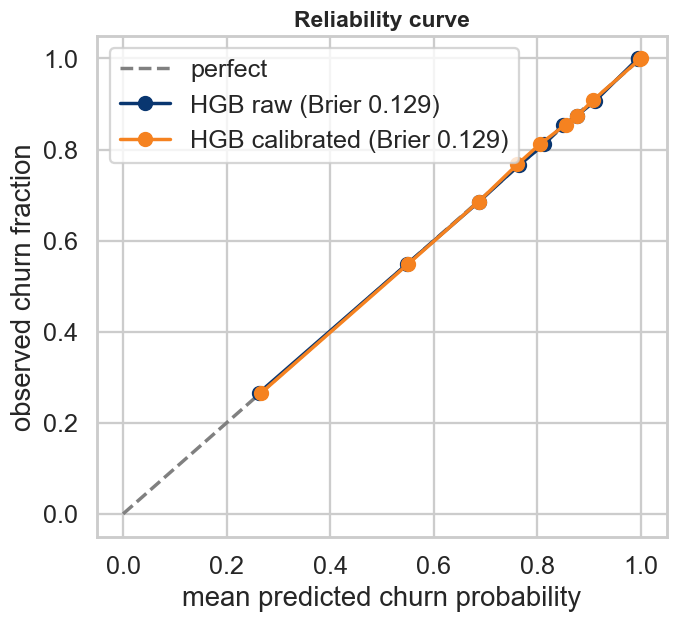

count    69624.000
mean         0.770
std          0.218
min          0.000
25%          0.689
50%          0.829
75%          0.896
max          1.000

Brier score  : raw 0.129  vs  calibrated 0.129  (lower is better)
Isotonic pile-up: 14.8% of users mapped to >= 0.999 (top 21.1% are >= 0.99) -> little ranking resolution up there


In [34]:
if HAS_LABELS:
    # Reuses X_train / X_test / y_train / y_test from §6 (same seed -> identical split).
    # Unweighted HGB here: probabilities should reflect the true base rate.
    raw = make_hgb().fit(X_train, y_train)
    p_raw = raw.predict_proba(X_test)[:, 1]

    cal = CalibratedClassifierCV(make_hgb(), method="isotonic",
                                 cv=CALIBRATION_CV).fit(X_train, y_train)
    p_cal = cal.predict_proba(X_test)[:, 1]

    brier_raw = brier_score_loss(y_test, p_raw)
    brier_cal = brier_score_loss(y_test, p_cal)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
    for name, p, brier, c in [("HGB raw", p_raw, brier_raw, PALETTE[0]),
                              ("HGB calibrated", p_cal, brier_cal, PALETTE[1])]:
        frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", color=c,
                label=f"{name} (Brier {brier:.3f})")
    ax.set_xlabel("mean predicted churn probability")
    ax.set_ylabel("observed churn fraction")
    ax.set_title("Reliability curve"); ax.legend(); plt.show()

    print(pd.Series(p_cal).describe().round(3).to_string())
    print(f"\nBrier score  : raw {brier_raw:.3f}  vs  calibrated {brier_cal:.3f}  (lower is better)")
    print(f"Isotonic pile-up: {(p_cal >= 0.999).mean():.1%} of users mapped to >= 0.999 "
          f"(top {(p_cal >= 0.99).mean():.1%} are >= 0.99) -> little ranking resolution up there")


### 8.2 Value-based targeting

A retention contact only pays off when its **expected value is positive**, and that value
differs by user: saving a high-spending customer is worth far more than saving a one-time
browser. So instead of a single flat `RETAIN_VALUE` for everyone, we use each user's **October
`total_spend` as a proxy for customer lifetime value (CLV)**. Contacting a user is worth

> **EV(contact) = p(churn) · uplift · value_user − contact cost**

and we contact everyone whose **EV > 0**. With cost = \$2.70 and uplift = 0.12 held fixed, this
is exactly a **value-risk** rule: contact when `p(churn) × spend` exceeds cost/uplift = **\$22.50**.
It automatically concentrates spend on users who are both likely to churn and worth saving -
rather than collapsing onto the highest-probability but near-worthless segment, which is what a
flat value does. (With a flat value the rule reduces to a pure probability cutoff, and as the
previous version of this table showed, targeted **44%** of the near-\$0-spend "stale" persona
while sparing the high-value repeat buyers, directly contradicting the revenue-at-risk view in §7c.)

*Caveat: the dollar inputs (cost, uplift, value) are **illustrative assumptions**, and the
targeted fraction is **highly sensitive** to them - read the specific % below as a worked
example, not a fixed recommendation. October `total_spend` is only a **proxy** for true CLV.
Also note the reported "precision" below is the **share of targeted users who actually churn**,
not campaign effectiveness (how many we would truly retain depends on the uplift assumption).*

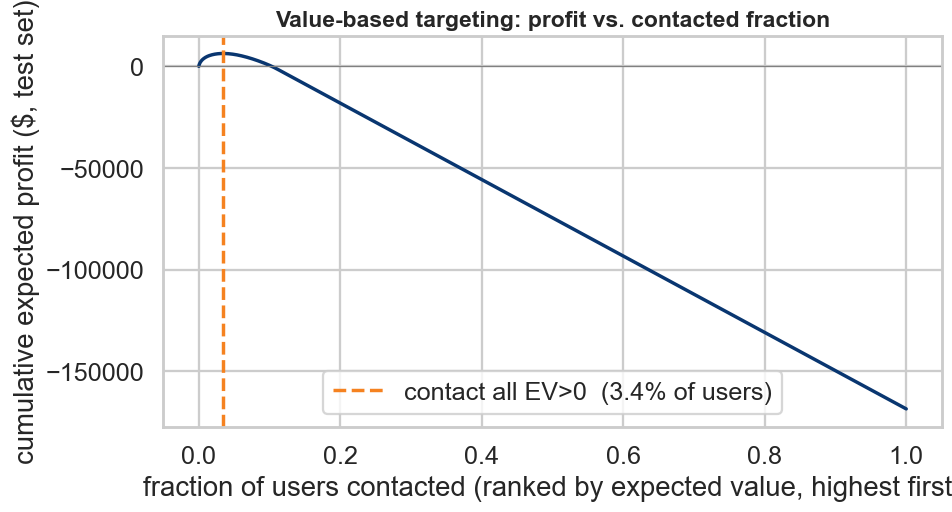

Value-risk break-even (p*spend) : $22.50  (contact if churn_prob x spend exceeds this)
Users targeted (EV>0, test set) : 2,388 of 69,624 (3.4%)
Of targeted, actually churned   : 60.1% (share of targeted who churn -- NOT campaign lift)
Mean Oct spend, targeted vs not : $81.09 vs $2.56
Expected profit (sum of EV>0)   : $6,382


In [35]:
if HAS_LABELS:
    # Per-user value: October total_spend as a PROXY for CLV (caveats above);
    # COST and UPLIFT are set in the configuration cell.
    value_test = feat["total_spend"].loc[X_test.index].to_numpy()
    scores = p_cal                                  # calibrated churn probabilities (test set)

    # Expected value of contacting each user, paid off by THAT user's own spend:
    #   EV = p(churn) * uplift * value - cost   ->   contact whenever EV > 0
    ev = scores * UPLIFT * value_test - COST
    targeted = ev > 0
    break_even = COST / UPLIFT                      # value-risk break-even: p(churn) * spend

    # Rank users by EV once; the sorted cumulative profit is reused by the top-K cell below
    order_ev = np.argsort(-ev)
    cum_profit = np.cumsum(ev[order_ev])
    frac_grid = (np.arange(len(ev)) + 1) / len(ev)
    opt_frac = targeted.mean()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(frac_grid, cum_profit, color=PALETTE[0])
    ax.axvline(opt_frac, ls="--", color=PALETTE[1],
               label=f"contact all EV>0  ({opt_frac:.1%} of users)")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xlabel("fraction of users contacted (ranked by expected value, highest first)")
    ax.set_ylabel("cumulative expected profit ($, test set)")
    ax.set_title("Value-based targeting: profit vs. contacted fraction"); ax.legend(); plt.show()

    print(f"Value-risk break-even (p*spend) : ${break_even:.2f}  (contact if churn_prob x spend exceeds this)")
    print(f"Users targeted (EV>0, test set) : {targeted.sum():,} of {len(scores):,} ({targeted.mean():.1%})")
    print(f"Of targeted, actually churned   : {y_test[targeted].mean():.1%} "
          f"(share of targeted who churn -- NOT campaign lift)")
    print(f"Mean Oct spend, targeted vs not : ${value_test[targeted].mean():.2f} vs ${value_test[~targeted].mean():.2f}")
    print(f"Expected profit (sum of EV>0)   : ${ev[targeted].sum():,.0f}")


In [36]:
# ---------- SENSITIVITY GRID (§14.3): quét 3 cost × 3 uplift ----------
# Tái dùng scores, value_test, y_test đã tính ở trên; chỉ COST/UPLIFT thay đổi.
COST_GRID   = [1.35, 2.70, 5.40]     # low / base / high
UPLIFT_GRID = [0.06, 0.12, 0.24]     # low / base / high

print(f"\n{'cost':>6} {'uplift':>7} {'break-even':>11} "
      f"{'targeted':>10} {'share':>7} {'churn%':>7} {'profit($)':>11}")
print("-" * 62)
for c in COST_GRID:
    for u in UPLIFT_GRID:
        ev_g       = scores * u * value_test - c          # EV = p * uplift * value - cost
        tgt_g      = ev_g > 0
        be_g       = c / u                                # value-risk break-even
        n_g        = tgt_g.sum()
        share_g    = tgt_g.mean()
        churn_g    = y_test[tgt_g].mean() if n_g else float("nan")
        profit_g   = ev_g[tgt_g].sum()
        flag = "  <-- base" if (c == COST and u == UPLIFT) else ""
        print(f"{c:>6.2f} {u:>7.2f} {be_g:>10.2f} "
              f"{n_g:>10,} {share_g:>6.1%} {churn_g:>6.1%} {profit_g:>11,.0f}{flag}")


  cost  uplift  break-even   targeted   share  churn%   profit($)
--------------------------------------------------------------
  1.35    0.06      22.50      2,388   3.4%  60.1%       3,191
  1.35    0.12      11.25      4,627   6.6%  58.5%      10,925
  1.35    0.24       5.63      6,527   9.4%  57.4%      29,351
  2.70    0.06      45.00        720   1.0%  61.4%       1,353
  2.70    0.12      22.50      2,388   3.4%  60.1%       6,382  <-- base
  2.70    0.24      11.25      4,627   6.6%  58.5%      21,850
  5.40    0.06      90.00        153   0.2%  66.0%         431
  5.40    0.12      45.00        720   1.0%  61.4%       2,706
  5.40    0.24      22.50      2,388   3.4%  60.1%      12,764


#### 8.2b Budget-constrained top-K (by expected value)

The `EV > 0` rule above contacts everyone who clears break-even. If instead you have a **fixed
outreach budget**, you can only afford to contact K users, the natural rule is to **rank by
expected value and take the top K**. The cell below contacts the top 15% by EV and reports the
profit, so a fixed-budget campaign can be compared against the unconstrained `EV > 0` optimum.

Because the value term now drives the ranking (and, per §8.1, calibrated risk barely
distinguishes users inside the top tier), the top-K here is dominated by **high-spend** users,
not merely the highest-probability ones. As above, the reported **"precision" is the share of
targeted users who actually churn, not campaign effectiveness.**

Budget                         : top 15% by EV (10,443 of 69,624 users)
Of top-K, actually churned     : 60.5% (share targeted who churn, not lift)
Mean Oct spend, top-K vs rest  : $34.52 vs $0.08
Expected profit, top-K budget  : $-8,651
Expected profit, all EV>0       : $6,382  (3.4% of users)


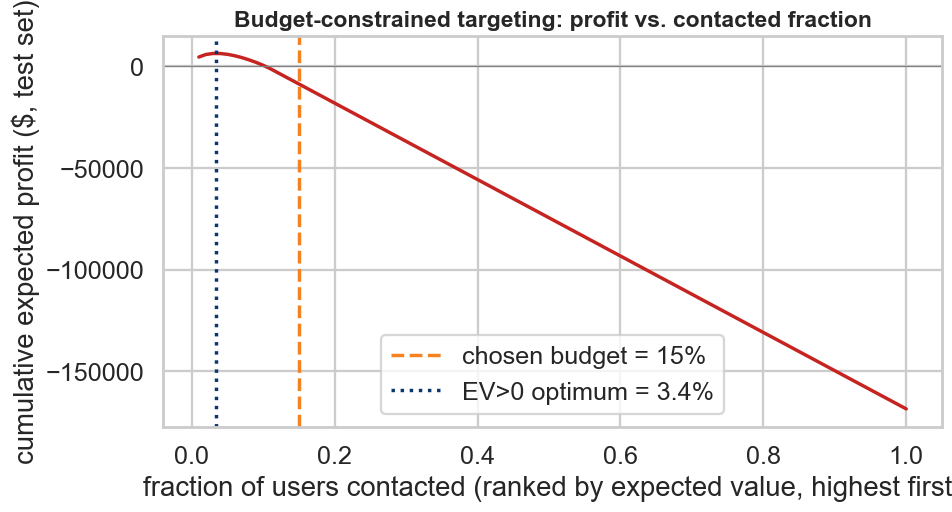

In [37]:
if HAS_LABELS:
    # Budget-constrained top-K: fixed budget, ranked by expected value (BUDGET_FRAC in config)
    K = int(BUDGET_FRAC * len(scores))
    topk_mask = np.zeros(len(scores), dtype=bool)
    topk_mask[order_ev[:K]] = True
    profit_topk = cum_profit[K - 1]                 # == ev[topk_mask].sum(), via the sorted cumsum

    print(f"Budget                         : top {BUDGET_FRAC:.0%} by EV ({K:,} of {len(scores):,} users)")
    print(f"Of top-K, actually churned     : {y_test[topk_mask].mean():.1%} (share targeted who churn, not lift)")
    print(f"Mean Oct spend, top-K vs rest  : ${value_test[topk_mask].mean():.2f} vs ${value_test[~topk_mask].mean():.2f}")
    print(f"Expected profit, top-K budget  : ${profit_topk:,.0f}")
    print(f"Expected profit, all EV>0       : ${ev[targeted].sum():,.0f}  ({targeted.mean():.1%} of users)")

    # Profit at each budget fraction, read straight off the cumulative-profit curve
    budget_grid = np.linspace(0.01, 1.0, 100)
    budget_idx = np.maximum((budget_grid * len(ev)).astype(int), 1) - 1
    budget_profit = cum_profit[budget_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(budget_grid, budget_profit, color=PALETTE[2])
    ax.axvline(BUDGET_FRAC, ls="--", color=PALETTE[1], label=f"chosen budget = {BUDGET_FRAC:.0%}")
    ax.axvline(targeted.mean(), ls=":", color=PALETTE[0], label=f"EV>0 optimum = {targeted.mean():.1%}")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xlabel("fraction of users contacted (ranked by expected value, highest first)")
    ax.set_ylabel("cumulative expected profit ($, test set)")
    ax.set_title("Budget-constrained targeting: profit vs. contacted fraction"); ax.legend(); plt.show()


### 8.3 Persona-level targeted strategies

Combining the calibrated risk score with the behavioural personas (§7b) turns the model into a
per‑segment playbook, who to contact, with what, and how hard to spend. Spend is
concentrated where value is high and risk has just started to rise (the recoverable middle),
not on the huge stale tier where expected payoff is lowest.

| Persona (§7b) | Size | Churn | Profile | Targeted strategy | Channel / spend |
|---|---|---|---|---|---|
| **Champions** | ~3.7% | ~28% | Recent, frequent, top spend | **Protect & reward** — loyalty perks, early access, referral | Low spend, retain goodwill |
| **Efficient repeat buyers** | ~6.8% | ~65% | High value but recency slipping | **Win‑back + replenishment** — "running low?" restock reminder, VIP return coupon | **Highest‑ROI target**, EDM/SMS |
| **Cart hoarders / researchers** | ~6.4% | ~50% | Many carts, no purchase | **Cart‑abandonment nudge** — price‑drop / back‑in‑stock alerts on carted items | Triggered email/push |
| **Fresh light browsers** | ~11.8% | ~58% | Just arrived, shallow | **Onboarding** — first‑purchase incentive, surface variety | Automated onboarding flow |
| **Passive one‑and‑done** | ~23% | ~77% | 2+ events, no depth | **Low‑cost remarketing** — retargeting pixel, email capture only | Cheap channels only |
| **Stale / disengaged** | ~48% | ~91% | Long gap, no intent | **Minimal / suppress** — lowest expected payoff; don't overspend | Broad remarketing at most |

Operationally: run the value-based `EV > 0` rule from §8.2 within each persona so budget
flows to high‑value, newly‑at‑risk users first. The table below applies that rule and confirms
the intended shift - targeting weight now lands on the **high-spend personas (1 - Efficient
repeat buyers, 5 - Champions)** and drops to near-zero on the huge but near-\$0-spend **persona 2
(Stale / disengaged)**, the opposite of the flat-value behaviour. The "Efficient repeat buyers"
and "Cart hoarders" rows are where the tiered nudge from §4.3b / A/B design (§11) should be
tested first.

In [38]:
if HAS_LABELS and "persona" in prof_feat.columns:
    # Deployment-style application: score EVERY October user (train + test) with the
    # calibrated model and apply the value-based EV>0 rule within each persona.
    # This is an *application* of the fitted model, not an evaluation — evaluation
    # metrics above always use the held-out test set only.
    risk_all  = pd.Series(cal.predict_proba(X)[:, 1], index=feat["user_id"].values,
                          name="churn_risk")
    value_all = feat.set_index("user_id")["total_spend"].reindex(risk_all.index)
    ev_all    = risk_all.values * UPLIFT * value_all.values - COST
    tgt_all   = pd.Series(ev_all > 0, index=risk_all.index, name="targeted")

    joined = (prof_feat
              .join(risk_all)
              .join(value_all.rename("clv_proxy"))
              .join(tgt_all))
    action = (joined.groupby("persona")
              .agg(n_users=("recency_days", "size"),
                   mean_churn_risk=("churn_risk", "mean"),
                   mean_spend=("clv_proxy", "mean"),
                   median_recency=("recency_days", "median"))
              .round(3))
    action["pct_targeted"] = joined.groupby("persona")["targeted"].mean().round(3)
    action = action.sort_values("pct_targeted", ascending=False)
    print(action.to_string())
    print(f"\nOverall targeted: {joined['targeted'].mean():.1%} of {len(joined):,} users")


         n_users  mean_churn_risk  mean_spend  median_recency  pct_targeted
persona                                                                    
1          15888            0.650      38.677            16.0         0.374
5           8497            0.274      68.323             2.0         0.216
4          27282            0.583       0.396             1.0         0.002
0          54143            0.763       0.034             9.0         0.000
2         111339            0.910       0.025            25.0         0.000
3          14930            0.514       0.017             9.0         0.000

Overall targeted: 3.4% of 232,079 users


**Insight:** The value-based rule concentrates spend exactly where §7c said the exposure sits.
**37.4% of Efficient repeat buyers (persona 1)** and **21.6% of Champions (persona 5)** are
targeted, which are the two highest-spend personas (mean Oct spend \$38.7 and \$68.3), while the huge,
near-\$0-spend **Stale / disengaged tier (persona 2) collapses to 0.0% targeted** despite
having the highest mean churn risk (0.91), personas 0, 3 and 4 likewise round to ≈0%
(≤0.2%). Overall only **3.4% of the 232,079 October users** clear the EV > 0 bar — a sharp
contrast with the earlier flat-value rule, which had poured **44%** of contacts into the stale
tier. Budget now follows **revenue at risk (risk × value)**, not raw churn probability,
consistent with the §7c revenue-at-risk ranking.


## 9. Insights summary

1. **The funnel leaks hardest at cart → purchase** — intent is high, conversion is not.
2. **Engagement is single‑session dominated** — most users never form a habit, so early
   depth is decisive.
3. **Retention decays steeply after week 0** — churn signals must be read from week‑1
   behaviour, not from later inactivity (which is already too late, and is what made the
   old label leak).
4. **High‑value shoppers churn less but cost more when lost** — the RFM segment with the highest frequency and spend (Segment 1, $80.1 avg spend) still churns at 42.1%, only modestly below the champions tier (37.9%), while the largest, lowest‑value segment (Segment 3, 9,529 buyers) churns at 65.7%, a priority segment for high‑value protection, not broad‑based retention spend.
5. **The model separates churners well ahead of the 77.1% base rate** — ROC‑AUC 0.80–0.82 for both models (the headline metric; PR‑AUC 0.93-0.94 looks higher but is inflated by the high base rate, whose no‑skill PR‑AUC is already ~0.77). Recency (`days_since_last_active`) is the single strongest, most consistent driver of churn risk, with breadth and tenure (`cat_breadth`, `active_days`) protective; after dropping two collinear features, all nine remaining predictors agree in sign and importance across both models.

These translate directly into levers below.

## 10. Recommendations

| # | Lever | Rationale | Success metric |
|---|-------|-----------|----------------|
| 1 | 48‑hour cart‑abandonment nudge for new users | Cart→purchase is the biggest leak; recover intent while it's warm | 60‑day return rate; cart→purchase conversion |
| 2 | Early‑activation onboarding (surface variety in first session) | Breadth & multi‑session depth predict return; most users are one‑and‑done | sessions/user in week 1; week‑1→week‑2 retention |
| 3 | High‑value retention programme targeting at‑risk high spenders | Highest‑cost churn segment | churn rate among high‑value tier |

Each lever is phrased as a testable hypothesis with a primary metric, which sets up the
experiment below.

## 11. Validation / experimentation (A/B testing)

> This dataset is **observational**, there is no randomised treatment,
> so nothing here is a real A/B test, and two pre‑existing user groups must **not** be
> compared as if they were randomised (that would be the same class of error as the leakage
> above). What follows is the **experiment we would run** for Recommendation #1, the
> **sample‑size/power** it requires (grounded in the data's own baseline), and a
> **simulated analysis** demonstrating the statistics, which is clearly labelled as a simulation.

**Design.** 

*Hypothesis:* a 48‑hour cart‑abandonment nudge for new users raises the 60‑day
return rate. 

*Unit:* user. 

*Primary metric:* 60‑day return rate (= 1 - churn).

*Guardrails:* notification opt‑out rate, revenue/user. 

*Analysis:* two‑proportion z‑test
with a 95% CI on the lift; check for sample‑ratio mismatch; fix the sample size in advance
(no peeking).

In [39]:
# All experiment constants (ABS_MDE, ALPHA, POWER, DAILY_ELIGIBLE, ...) live in the config cell.
# baseline = observed return rate; falls back to a placeholder when labels are absent
BASELINE_RETURN = (1 - feat["churn"].mean()) if HAS_LABELS else FALLBACK_BASELINE_RETURN
p0, p1 = BASELINE_RETURN, BASELINE_RETURN + ABS_MDE

z_alpha, z_power = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(POWER)
n_per_arm = int(np.ceil((z_alpha + z_power)**2 * (p0*(1-p0) + p1*(1-p1)) / (p1 - p0)**2))
days = int(np.ceil(2 * n_per_arm / DAILY_ELIGIBLE))
print("EXPERIMENT DESIGN")
print(f"  Baseline return   : {p0:.1%}"
      + ("" if HAS_LABELS else "   (placeholder until labels present)"))
print(f"  Target (+{ABS_MDE:.0%})     : {p1:.1%}")
print(f"  Per arm / total   : {n_per_arm:,} / {2*n_per_arm:,} users")
print(f"  Duration (~{DAILY_ELIGIBLE:,}/day): ~{days} days")


EXPERIMENT DESIGN
  Baseline return   : 22.9%
  Target (+3%)     : 25.9%
  Per arm / total   : 3,216 / 6,432 users
  Duration (~5,000/day): ~2 days


In [40]:
# Simulated analysis (illustrative — NOT real experiment data)
rng = np.random.default_rng(RANDOM_STATE)
TRUE_TREAT = p0 + SIM_TRUE_LIFT       # assume a true lift somewhat above the MDE
control = rng.binomial(1, p0, n_per_arm)
treat   = rng.binomial(1, TRUE_TREAT, n_per_arm)


def two_prop_z(a, b, alpha=0.05):
    """Two-proportion z-test: rates, lift, z, p-value and a 95% CI on the lift."""
    x1, n1, x2, n2 = a.sum(), len(a), b.sum(), len(b)
    p1h, p2h = x1/n1, x2/n2
    pooled = (x1 + x2)/(n1 + n2)
    z = (p2h - p1h)/np.sqrt(pooled*(1-pooled)*(1/n1 + 1/n2))
    pval = 2*(1 - stats.norm.cdf(abs(z)))
    se = np.sqrt(p1h*(1-p1h)/n1 + p2h*(1-p2h)/n2)
    ci = ((p2h-p1h) - stats.norm.ppf(1-alpha/2)*se, (p2h-p1h) + stats.norm.ppf(1-alpha/2)*se)
    return p1h, p2h, p2h-p1h, z, pval, ci


pc, pt, lift, z, pval, ci = two_prop_z(control, treat)
print("SIMULATED RESULT")
print(f"  Control / Treatment : {pc:.3f} / {pt:.3f}")
print(f"  Lift                : {lift:+.3f}  (95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}])")
print(f"  z = {z:.2f},  p = {pval:.4f}  -> "
      + ("significant" if pval < ALPHA else "not significant"))
srm = stats.chisquare([len(control), len(treat)], [n_per_arm]*2).pvalue
print(f"  SRM check (p)       : {srm:.3f}  ({'balanced' if srm>0.01 else 'IMBALANCED'})")


SIMULATED RESULT
  Control / Treatment : 0.233 / 0.261
  Lift                : +0.028  (95% CI [+0.007, +0.049])
  z = 2.63,  p = 0.0085  -> significant
  SRM check (p)       : 1.000  (balanced)


In [41]:
# ---- Why not to peek: A/A false-positive inflation ---------------------------
def peeking_fpr(n_sim=PEEK_N_SIM, n_final=n_per_arm, looks=PEEK_LOOKS, p=p0, alpha=ALPHA):
    r = np.random.default_rng(RANDOM_STATE)
    single = peek = 0
    checkpoints = np.linspace(n_final//looks, n_final, looks).astype(int)
    for _ in range(n_sim):
        a, b = r.binomial(1, p, n_final), r.binomial(1, p, n_final)
        if two_prop_z(a, b)[4] < alpha: single += 1
        if any(two_prop_z(a[:c], b[:c])[4] < alpha for c in checkpoints): peek += 1
    return single/n_sim, peek/n_sim


fpr_single, fpr_peek = peeking_fpr()
print("PEEKING PITFALL (A/A test, true false-positive rate should be ~5%)")
print(f"  Look once at the end : {fpr_single:.1%}")
print(f"  Peek 5x, stop early  : {fpr_peek:.1%}  <- inflated")
print("  => fix N in advance, or use sequential testing / alpha-spending.")


PEEKING PITFALL (A/A test, true false-positive rate should be ~5%)
  Look once at the end : 4.8%
  Peek 5x, stop early  : 13.7%  <- inflated
  => fix N in advance, or use sequential testing / alpha-spending.


## 12. Limitations & next steps

* **Non‑return ≠ subscription churn:** "Churn" here means no return in ~60 days on a
  browse‑heavy store.
* **No demographics / marketing channel**, so no attribution - recommendations are
  product/UX, not acquisition.
* **Observational data:** the A/B section is design + simulation, for causal estimates on
  the historical data, use a quasi‑experiment (propensity‑score matching or
  difference‑in‑differences).
* **Next:** extend the cohort grid across all five months, test the tiered nudge from §4.3b
  / §11 in a real experiment. (A gradient‑boosting benchmark and probability calibration for
  targeting thresholds are now implemented in §6 and §8, respectively).